# Projeto 2 — Reconhecimento de Atividades Humanas com GRU

Este notebook desenvolve o segundo projeto da disciplina de Redes Neurais Profundas, aplicando um pipeline completo de deep learning a dados sequenciais. O problema escolhido é o reconhecimento de atividades humanas a partir de sinais de sensores do dataset Human Activity Recognition Using Smartphones, disponibilizado pelo UCI Machine Learning Repository.

Diferentemente do Projeto 1, no qual cada observação era representada por um vetor independente de características, neste projeto cada exemplo possui uma sequência temporal de medições de acelerômetro e giroscópio. Essa estrutura torna uma arquitetura recorrente apropriada para o problema.

A arquitetura principal será uma Gated Recurrent Unit (GRU), implementada diretamente com PyTorch. O treinamento incluirá DataLoader, validação por época, checkpoint do melhor modelo por `state_dict`, learning rate scheduling, TensorBoard, métricas de classificação e análise de estabilidade. A avaliação final será realizada somente no conjunto de teste, após a seleção definitiva da configuração utilizando os dados de validação.

## Ambiente e reprodutibilidade

O projeto utiliza o mesmo ambiente PyTorch configurado para o assessment, mas os hiperparâmetros e a arquitetura serão definidos especificamente para o domínio temporal. Uma semente fixa será utilizada nas bibliotecas relevantes para reduzir variações entre execuções e permitir comparações controladas entre experimentos.

In [1]:
from pathlib import Path
import random
import urllib.request
import zipfile
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import torch
import torch.nn as nn

from sklearn.model_selection import GroupShuffleSplit
from torch.utils.data import DataLoader, TensorDataset
from torch.utils.tensorboard import SummaryWriter

In [2]:
def find_repository_root(start_path):
    start_path = Path(start_path).resolve()

    for candidate in [
        start_path,
        *start_path.parents,
    ]:
        if (
            (candidate / "environment.yml").exists()
            and (candidate / "project_2_gru").exists()
        ):
            return candidate

    raise FileNotFoundError(
        "Repository root could not be found."
    )


REPO_ROOT = find_repository_root(
    Path.cwd()
)

PROJECT_DIR = (
    REPO_ROOT
    / "project_2_gru"
)

DATA_DIR = (
    PROJECT_DIR
    / "data"
)

CHECKPOINT_DIR = (
    PROJECT_DIR
    / "checkpoints"
)

ARTIFACTS_DIR = (
    PROJECT_DIR
    / "artifacts"
)

RUNS_DIR = (
    REPO_ROOT
    / "runs"
)

for directory in [
    DATA_DIR,
    CHECKPOINT_DIR,
    ARTIFACTS_DIR,
    RUNS_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

print(
    f"Repository root: {REPO_ROOT}"
)

print(
    f"Project directory: {PROJECT_DIR}"
)

print(
    f"Data directory: {DATA_DIR}"
)

Repository root: C:\Users\breno\Desktop\Redes Neurais Profundas - Assessment
Project directory: C:\Users\breno\Desktop\Redes Neurais Profundas - Assessment\project_2_gru
Data directory: C:\Users\breno\Desktop\Redes Neurais Profundas - Assessment\project_2_gru\data


In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(
    f"PyTorch version: {torch.__version__}"
)

print(
    f"scikit-learn version: {sklearn.__version__}"
)

print(
    f"CUDA available: {torch.cuda.is_available()}"
)

print(
    f"Device: {DEVICE}"
)

PyTorch version: 2.13.0+cpu
scikit-learn version: 1.9.0
CUDA available: False
Device: cpu


## Escolha do problema e da arquitetura

O Human Activity Recognition Using Smartphones é um problema de classificação multiclasse baseado em sequências temporais. Os sinais foram registrados por acelerômetro e giroscópio de um smartphone utilizado na cintura dos participantes durante seis atividades: caminhar, subir escadas, descer escadas, sentar, ficar em pé e deitar.

Os sensores foram amostrados a 50 Hz e organizados em janelas de 2,56 segundos, correspondentes a 128 timesteps. Para preservar essa estrutura temporal, serão utilizados os sinais inerciais das janelas, em vez do vetor de 561 características estatísticas disponibilizado como representação derivada do mesmo dataset.

Cada exemplo será representado por uma matriz com 128 timesteps e nove canais: três componentes de aceleração corporal, três componentes de velocidade angular do giroscópio e três componentes de aceleração total.

A GRU foi escolhida porque mantém um estado oculto capaz de acumular informação ao longo da sequência, permitindo modelar dependências temporais entre diferentes momentos da atividade. Em comparação com uma MLP aplicada aos valores achatados, a arquitetura possui um viés indutivo diretamente relacionado à ordem temporal dos sensores. Em comparação com uma LSTM, a GRU utiliza uma estrutura de gates mais simples e menor quantidade de parâmetros, característica adequada para sequências curtas a médias e para um problema em que eficiência computacional também é desejável.

## Aquisição do dataset

O arquivo original do UCI HAR será utilizado porque contém as janelas dos sinais inerciais necessárias para a arquitetura recorrente. O download será realizado automaticamente a partir do UCI Machine Learning Repository para que o notebook possa ser reproduzido sem preparação manual do dataset.

Os dados já possuem uma separação oficial entre treino e teste baseada em participantes diferentes e essa separação será preservada integralmente. O conjunto oficial de treino será posteriormente subdividido em treino e validação também por participante, evitando que janelas sobrepostas provenientes da mesma pessoa apareçam simultaneamente nas duas partições.

In [4]:
DATASET_URL = (
    "https://archive.ics.uci.edu/static/public/240/"
    "human%2Bactivity%2Brecognition%2Busing%2Bsmartphones.zip"
)

DATASET_ZIP_PATH = (
    DATA_DIR
    / "uci_har_dataset.zip"
)

if not DATASET_ZIP_PATH.exists():
    print(
        "Downloading UCI HAR dataset..."
    )

    urllib.request.urlretrieve(
        DATASET_URL,
        DATASET_ZIP_PATH,
    )

    print(
        "Download completed."
    )
else:
    print(
        "Dataset archive already available."
    )


def find_dataset_directory(data_dir):
    candidates = list(
        data_dir.rglob(
            "activity_labels.txt"
        )
    )

    if candidates:
        return candidates[0].parent.resolve()

    return None


DATASET_DIR = find_dataset_directory(
    DATA_DIR
)

if DATASET_DIR is None:
    print(
        "Extracting main archive..."
    )

    with zipfile.ZipFile(
        DATASET_ZIP_PATH,
        "r",
    ) as zip_file:
        zip_file.extractall(
            DATA_DIR
        )

    print(
        "Main archive extracted."
    )

    DATASET_DIR = find_dataset_directory(
        DATA_DIR
    )


if DATASET_DIR is None:
    nested_archives = [
        path
        for path in DATA_DIR.rglob("*.zip")
        if path.resolve()
        != DATASET_ZIP_PATH.resolve()
    ]

    print(
        f"Nested archives found: "
        f"{len(nested_archives)}"
    )

    for archive_path in nested_archives:
        print(
            f"Extracting nested archive: "
            f"{archive_path.name}"
        )

        with zipfile.ZipFile(
            archive_path,
            "r",
        ) as zip_file:
            zip_file.extractall(
                archive_path.parent
            )

        DATASET_DIR = find_dataset_directory(
            DATA_DIR
        )

        if DATASET_DIR is not None:
            break


if DATASET_DIR is None:
    raise FileNotFoundError(
        "UCI HAR Dataset directory could not be located."
    )


print(
    f"\nDataset directory: "
    f"{DATASET_DIR}"
)

print(
    f"Dataset exists: "
    f"{DATASET_DIR.exists()}"
)

print(
    f"Activity labels exist: "
    f"{(DATASET_DIR / 'activity_labels.txt').exists()}"
)

print(
    f"Train directory exists: "
    f"{(DATASET_DIR / 'train').exists()}"
)

print(
    f"Test directory exists: "
    f"{(DATASET_DIR / 'test').exists()}"
)

Dataset archive already available.

Dataset directory: C:\Users\breno\Desktop\Redes Neurais Profundas - Assessment\project_2_gru\data\UCI HAR Dataset
Dataset exists: True
Activity labels exist: True
Train directory exists: True
Test directory exists: True


In [5]:
SIGNAL_NAMES = [
    "body_acc_x",
    "body_acc_y",
    "body_acc_z",
    "body_gyro_x",
    "body_gyro_y",
    "body_gyro_z",
    "total_acc_x",
    "total_acc_y",
    "total_acc_z",
]


def load_inertial_split(
    dataset_dir,
    split,
):
    signal_dir = (
        dataset_dir
        / split
        / "Inertial Signals"
    )

    signal_arrays = []

    for signal_name in SIGNAL_NAMES:
        signal_path = (
            signal_dir
            / f"{signal_name}_{split}.txt"
        )

        signal_array = np.loadtxt(
            signal_path,
            dtype=np.float32,
        )

        signal_arrays.append(
            signal_array
        )

    features = np.stack(
        signal_arrays,
        axis=2,
    )

    labels = np.loadtxt(
        dataset_dir
        / split
        / f"y_{split}.txt",
        dtype=np.int64,
    )

    labels = labels - 1

    subjects = np.loadtxt(
        dataset_dir
        / split
        / f"subject_{split}.txt",
        dtype=np.int64,
    )

    return (
        features,
        labels,
        subjects,
    )


(
    X_official_train,
    y_official_train,
    subject_official_train,
) = load_inertial_split(
    DATASET_DIR,
    "train",
)

(
    X_test,
    y_test,
    subject_test,
) = load_inertial_split(
    DATASET_DIR,
    "test",
)

In [6]:
activity_labels = pd.read_csv(
    DATASET_DIR
    / "activity_labels.txt",
    sep=r"\s+",
    header=None,
    names=[
        "activity_id",
        "activity",
    ],
)

activity_labels[
    "class_index"
] = (
    activity_labels[
        "activity_id"
    ]
    - 1
)

ACTIVITY_NAMES = {
    row.class_index: row.activity
    for row
    in activity_labels.itertuples()
}

print(
    f"Official training shape: "
    f"{X_official_train.shape}"
)

print(
    f"Official test shape: "
    f"{X_test.shape}"
)

print(
    f"Sequence length: "
    f"{X_official_train.shape[1]}"
)

print(
    f"Sensor channels: "
    f"{X_official_train.shape[2]}"
)

print(
    f"Training subjects: "
    f"{len(np.unique(subject_official_train))}"
)

print(
    f"Test subjects: "
    f"{len(np.unique(subject_test))}"
)

print(
    "\nActivities:"
)

for class_index, activity_name in (
    ACTIVITY_NAMES.items()
):
    print(
        f"{class_index}: "
        f"{activity_name}"
    )

Official training shape: (7352, 128, 9)
Official test shape: (2947, 128, 9)
Sequence length: 128
Sensor channels: 9
Training subjects: 21
Test subjects: 9

Activities:
0: WALKING
1: WALKING_UPSTAIRS
2: WALKING_DOWNSTAIRS
3: SITTING
4: STANDING
5: LAYING


## Divisão entre treino, validação e teste

O split oficial do UCI HAR já separa os participantes utilizados no treino daqueles presentes no teste, de modo que o conjunto de teste será preservado sem alterações.

Para obter um conjunto de validação sem introduzir vazamento entre sequências relacionadas, a subdivisão do conjunto oficial de treino será realizada por sujeito, e não por janela individual. Isso é especialmente importante porque as sequências do dataset foram produzidas com 50% de sobreposição e duas janelas consecutivas do mesmo participante podem, portanto, compartilhar metade das medições originais.

Uma divisão aleatória entre janelas poderia colocar segmentos altamente semelhantes nos conjuntos de treino e validação e produzir uma estimativa excessivamente otimista de generalização. A separação por grupos garante que todos os exemplos de um determinado participante pertençam a apenas uma das duas partições.

In [7]:
group_splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=SEED,
)

train_indices, val_indices = next(
    group_splitter.split(
        X_official_train,
        y_official_train,
        groups=subject_official_train,
    )
)

X_train = X_official_train[
    train_indices
]

y_train = y_official_train[
    train_indices
]

subject_train = subject_official_train[
    train_indices
]

X_val = X_official_train[
    val_indices
]

y_val = y_official_train[
    val_indices
]

subject_val = subject_official_train[
    val_indices
]

train_subjects = set(
    np.unique(subject_train)
)

val_subjects = set(
    np.unique(subject_val)
)

test_subjects = set(
    np.unique(subject_test)
)

print(
    f"Training samples:   {len(X_train)}"
)

print(
    f"Validation samples: {len(X_val)}"
)

print(
    f"Test samples:       {len(X_test)}"
)

print(
    f"\nTraining subjects:   "
    f"{len(train_subjects)}"
)

print(
    f"Validation subjects: "
    f"{len(val_subjects)}"
)

print(
    f"Test subjects:       "
    f"{len(test_subjects)}"
)

print(
    "\nSubject overlap verification:"
)

print(
    "Train ∩ Validation: "
    f"{len(train_subjects & val_subjects)}"
)

print(
    "Train ∩ Test:       "
    f"{len(train_subjects & test_subjects)}"
)

print(
    "Validation ∩ Test:  "
    f"{len(val_subjects & test_subjects)}"
)

print(
    "\nValidation subject IDs:"
)

print(
    sorted(val_subjects)
)

Training samples:   5551
Validation samples: 1801
Test samples:       2947

Training subjects:   16
Validation subjects: 5
Test subjects:       9

Subject overlap verification:
Train ∩ Validation: 0
Train ∩ Test:       0
Validation ∩ Test:  0

Validation subject IDs:
[np.int64(1), np.int64(3), np.int64(15), np.int64(25), np.int64(27)]


In [8]:
def build_class_distribution(
    labels,
    dataset_name,
):
    counts = pd.Series(
        labels
    ).value_counts().sort_index()

    distribution = pd.DataFrame({
        "class_index": counts.index,
        "count": counts.values,
    })

    distribution[
        "activity"
    ] = distribution[
        "class_index"
    ].map(
        ACTIVITY_NAMES
    )

    distribution[
        "proportion"
    ] = (
        distribution["count"]
        / distribution["count"].sum()
    )

    distribution[
        "dataset"
    ] = dataset_name

    return distribution


train_class_distribution = (
    build_class_distribution(
        y_train,
        "Train",
    )
)

val_class_distribution = (
    build_class_distribution(
        y_val,
        "Validation",
    )
)

class_distribution = pd.concat(
    [
        train_class_distribution,
        val_class_distribution,
    ],
    ignore_index=True,
)

display(
    class_distribution
)

,class_index,count,activity,proportion,dataset
0,0,888,WALKING,0.159971,Train
1,1,797,WALKING_UPSTAIRS,0.143578,Train
2,2,744,WALKING_DOWNSTAIRS,0.134030,Train
3,3,993,SITTING,0.178887,Train
4,4,1053,STANDING,0.189696,Train
5,5,1076,LAYING,0.193839,Train
6,0,338,WALKING,0.187674,Validation
7,1,276,WALKING_UPSTAIRS,0.153248,Validation
8,2,242,WALKING_DOWNSTAIRS,0.134370,Validation
9,3,293,SITTING,0.162687,Validation


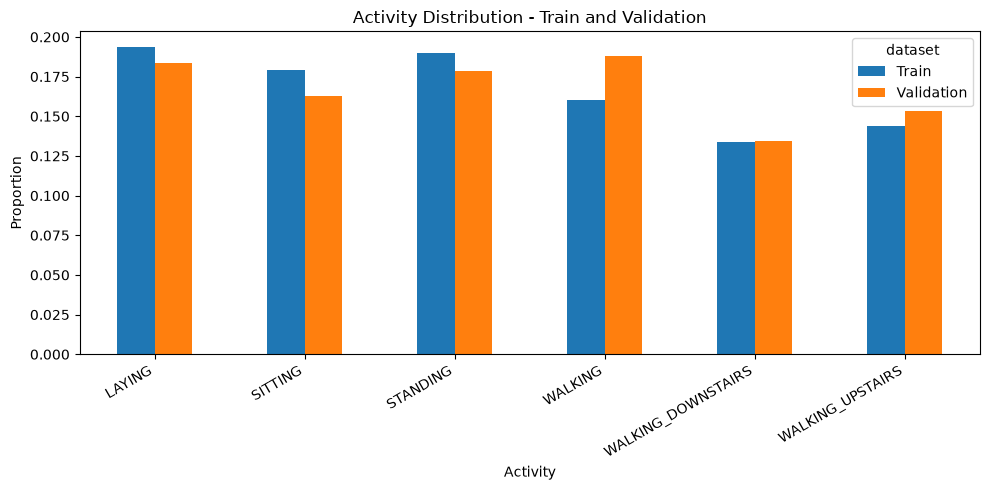

In [9]:
distribution_pivot = (
    class_distribution
    .pivot(
        index="activity",
        columns="dataset",
        values="proportion",
    )
)

distribution_pivot.plot(
    kind="bar",
    figsize=(10, 5),
)

plt.title(
    "Activity Distribution - Train and Validation"
)

plt.xlabel(
    "Activity"
)

plt.ylabel(
    "Proportion"
)

plt.xticks(
    rotation=30,
    ha="right",
)

plt.tight_layout()
plt.show()

## Inspeção dos sinais temporais

Antes do pré-processamento, serão visualizadas algumas sequências representativas das atividades. O objetivo é verificar como os nove canais variam ao longo dos 128 timesteps e confirmar que diferentes atividades apresentam padrões temporais distintos. Como a GRU recebe a sequência completa, essas diferenças ao longo do tempo são parte da informação que o modelo deve aprender, atividades dinâmicas, como caminhar e subir escadas, tendem a produzir oscilações mais pronunciadas nos sensores, enquanto atividades estáticas, como sentar e ficar em pé, apresentam comportamento temporal mais estável.

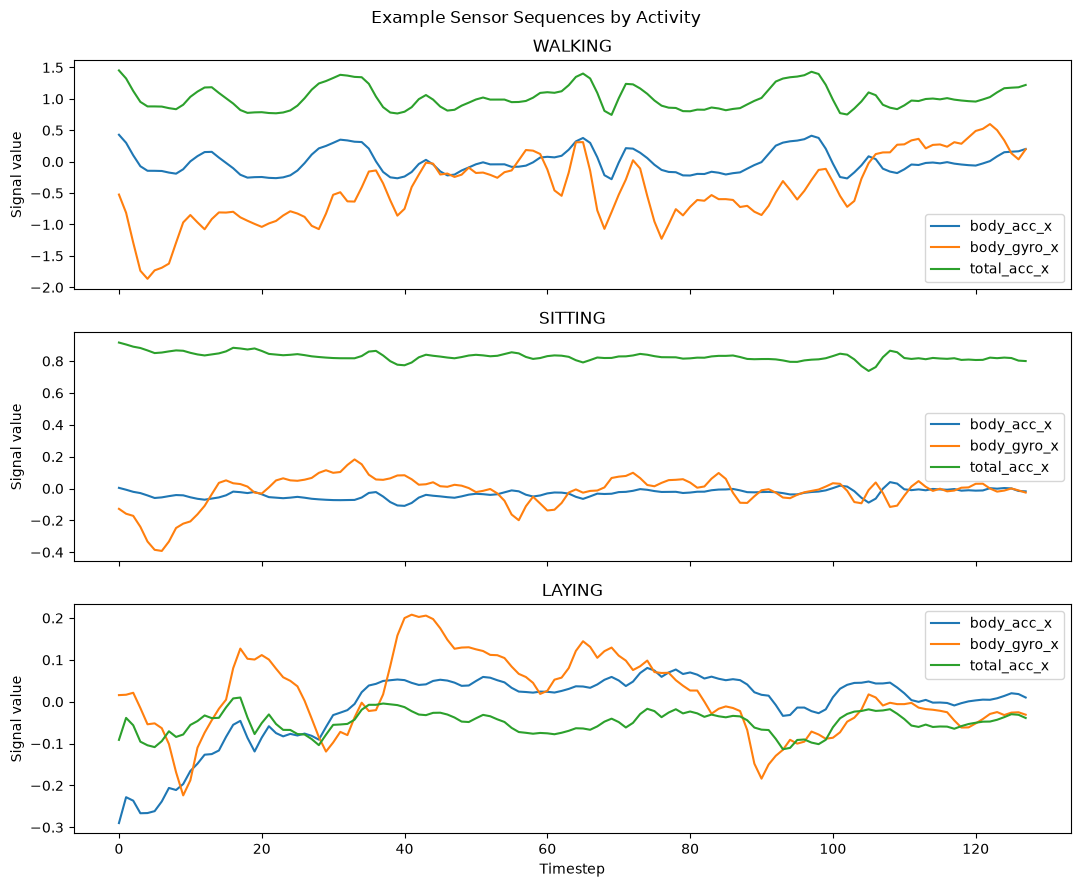

In [10]:
selected_signal_names = [
    "body_acc_x",
    "body_gyro_x",
    "total_acc_x",
]

selected_signal_indices = [
    SIGNAL_NAMES.index(signal_name)
    for signal_name in selected_signal_names
]

example_activities = [
    "WALKING",
    "SITTING",
    "LAYING",
]

fig, axes = plt.subplots(
    len(example_activities),
    1,
    figsize=(11, 9),
    sharex=True,
)

for axis, activity_name in zip(
    axes,
    example_activities,
):
    class_index = next(
        class_index
        for class_index, name
        in ACTIVITY_NAMES.items()
        if name == activity_name
    )

    sample_index = np.where(
        y_train == class_index
    )[0][0]

    sample = X_train[
        sample_index
    ]

    for signal_name, signal_index in zip(
        selected_signal_names,
        selected_signal_indices,
    ):
        axis.plot(
            sample[:, signal_index],
            label=signal_name,
        )

    axis.set_title(
        activity_name
    )

    axis.set_ylabel(
        "Signal value"
    )

    axis.legend()

axes[-1].set_xlabel(
    "Timestep"
)

fig.suptitle(
    "Example Sensor Sequences by Activity"
)

plt.tight_layout()
plt.show()

## Normalização dos canais

Os canais dos sensores possuem escalas e distribuições diferentes. Para evitar que canais de maior magnitude dominem as atualizações dos pesos, cada canal será padronizado separadamente utilizando apenas as estatísticas do conjunto de treino.

Para cada um dos nove canais, a média e o desvio padrão serão calculados considerando todas as amostras e todos os timesteps do treino. As mesmas estatísticas serão então aplicadas aos conjuntos de validação e teste, esse procedimento preserva a estrutura temporal de cada sequência e evita vazamento de informação das partições utilizadas para avaliação.

In [11]:
channel_mean = X_train.mean(
    axis=(0, 1),
    keepdims=True,
)

channel_std = X_train.std(
    axis=(0, 1),
    keepdims=True,
)

channel_std = np.where(
    channel_std < 1e-8,
    1.0,
    channel_std,
)

X_train_scaled = (
    X_train
    - channel_mean
) / channel_std

X_val_scaled = (
    X_val
    - channel_mean
) / channel_std

X_test_scaled = (
    X_test
    - channel_mean
) / channel_std

X_train_scaled = X_train_scaled.astype(
    np.float32
)

X_val_scaled = X_val_scaled.astype(
    np.float32
)

X_test_scaled = X_test_scaled.astype(
    np.float32
)

channel_statistics = pd.DataFrame({
    "signal": SIGNAL_NAMES,
    "train_mean_before": (
        channel_mean.reshape(-1)
    ),
    "train_std_before": (
        channel_std.reshape(-1)
    ),
    "train_mean_after": (
        X_train_scaled.mean(
            axis=(0, 1)
        )
    ),
    "train_std_after": (
        X_train_scaled.std(
            axis=(0, 1)
        )
    ),
})

display(
    channel_statistics.round(6)
)

,signal,train_mean_before,train_std_before,train_mean_after,train_std_after
0,body_acc_x,-0.000606,0.199087,0.000000,1.000009
1,body_acc_y,-0.000275,0.122160,0.000000,0.999993
2,body_acc_z,-0.000239,0.110410,0.000000,0.999970
3,body_gyro_x,0.000525,0.407488,0.000000,0.999996
4,body_gyro_y,-0.000929,0.392923,-0.000000,0.999998
5,body_gyro_z,-0.001074,0.266889,0.000000,0.999998
6,total_acc_x,0.799536,0.419294,0.000186,1.000078
7,total_acc_y,0.027383,0.383510,-0.000001,0.999988
8,total_acc_z,0.080250,0.375425,-0.000001,0.999969


## Baseline de classificação

Antes do treinamento da GRU será estabelecido um baseline não trivial utilizando Regressão Logística multinomial. Para esse modelo, cada sequência padronizada de dimensão `128 × 9` será achatada em um vetor com 1.152 valores.

Esse baseline utiliza exatamente as mesmas medições fornecidas à rede recorrente, mas não possui um mecanismo explícito de estado oculto para representar a evolução temporal. Dessa forma, ele fornece uma referência útil para avaliar se a arquitetura especializada consegue explorar a estrutura sequencial de forma vantajosa.

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    f1_score,
)

In [13]:
X_train_flat = X_train_scaled.reshape(
    len(X_train_scaled),
    -1,
)

X_val_flat = X_val_scaled.reshape(
    len(X_val_scaled),
    -1,
)

X_test_flat = X_test_scaled.reshape(
    len(X_test_scaled),
    -1,
)

print(
    f"Flattened training shape: "
    f"{X_train_flat.shape}"
)

print(
    f"Flattened validation shape: "
    f"{X_val_flat.shape}"
)

print(
    f"Flattened test shape: "
    f"{X_test_flat.shape}"
)

Flattened training shape: (5551, 1152)
Flattened validation shape: (1801, 1152)
Flattened test shape: (2947, 1152)


In [14]:
classification_baseline = LogisticRegression(
    max_iter=3000,
    random_state=SEED,
)

classification_baseline.fit(
    X_train_flat,
    y_train,
)

baseline_val_predictions = (
    classification_baseline.predict(
        X_val_flat
    )
)

baseline_val_accuracy = accuracy_score(
    y_val,
    baseline_val_predictions,
)

baseline_val_macro_f1 = f1_score(
    y_val,
    baseline_val_predictions,
    average="macro",
)

print(
    "Validation baseline metrics:"
)

print(
    f"Accuracy: "
    f"{baseline_val_accuracy:.4f}"
)

print(
    f"Macro F1: "
    f"{baseline_val_macro_f1:.4f}"
)

Validation baseline metrics:
Accuracy: 0.6502
Macro F1: 0.6095


In [15]:
(
    baseline_precision,
    baseline_recall,
    baseline_f1,
    baseline_support,
) = precision_recall_fscore_support(
    y_val,
    baseline_val_predictions,
    labels=list(
        ACTIVITY_NAMES.keys()
    ),
    zero_division=0,
)

baseline_class_metrics = pd.DataFrame({
    "class_index": list(
        ACTIVITY_NAMES.keys()
    ),
    "activity": [
        ACTIVITY_NAMES[class_index]
        for class_index
        in ACTIVITY_NAMES.keys()
    ],
    "precision": baseline_precision,
    "recall": baseline_recall,
    "f1": baseline_f1,
    "support": baseline_support,
})

display(
    baseline_class_metrics.round(4)
)

,class_index,activity,precision,recall,f1,support
0,0,WALKING,0.4550,0.2692,0.3383,338
1,1,WALKING_UPSTAIRS,0.6218,0.4348,0.5117,276
2,2,WALKING_DOWNSTAIRS,0.3875,0.2562,0.3085,242
3,3,SITTING,0.7264,0.9966,0.8403,293
4,4,STANDING,0.5358,0.8629,0.6611,321
5,5,LAYING,1.0000,0.9940,0.9970,331


## Conversão para PyTorch e DataLoaders

As sequências padronizadas serão convertidas para tensores `float32`, enquanto os rótulos serão armazenados como inteiros `long`, formato esperado pela `CrossEntropyLoss`.

Foi adotado batch size de 64, esse valor é maior que o utilizado no Projeto 1 porque o conjunto possui mais de cinco mil sequências de treino e permite processar um número maior de exemplos por atualização sem tornar cada batch excessivamente grande. Como cada amostra contém 128 timesteps e nove canais, o valor também mantém o custo computacional compatível com o treinamento em CPU.

In [16]:
X_train_tensor = torch.tensor(
    X_train_scaled,
    dtype=torch.float32,
)

X_val_tensor = torch.tensor(
    X_val_scaled,
    dtype=torch.float32,
)

X_test_tensor = torch.tensor(
    X_test_scaled,
    dtype=torch.float32,
)

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.long,
)

y_val_tensor = torch.tensor(
    y_val,
    dtype=torch.long,
)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.long,
)

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor,
)

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor,
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor,
)

BATCH_SIZE = 64


def create_dataloaders(
    seed=SEED,
):
    generator = torch.Generator()
    generator.manual_seed(seed)

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=generator,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
    )

    return (
        train_loader,
        val_loader,
        test_loader,
    )


train_loader, val_loader, test_loader = (
    create_dataloaders()
)

batch_features, batch_targets = next(
    iter(train_loader)
)

print(
    f"Feature batch shape: "
    f"{batch_features.shape}"
)

print(
    f"Target batch shape: "
    f"{batch_targets.shape}"
)

print(
    f"Feature dtype: "
    f"{batch_features.dtype}"
)

print(
    f"Target dtype: "
    f"{batch_targets.dtype}"
)

Feature batch shape: torch.Size([64, 128, 9])
Target batch shape: torch.Size([64])
Feature dtype: torch.float32
Target dtype: torch.int64


## Arquitetura GRU

A arquitetura principal utilizará duas camadas GRU empilhadas com `hidden_size` igual a 64. A entrada em cada timestep possui nove características, correspondentes aos nove canais dos sensores, e o estado oculto de 64 dimensões oferece capacidade suficiente para representar combinações temporais desses sinais sem criar uma rede excessivamente grande para o tamanho do conjunto de dados.

A utilização de duas camadas permite que a primeira GRU transforme os sinais brutos em uma representação temporal intermediária e que a segunda modele padrões de nível mais alto ao longo da janela. Foi adotado Dropout de 0,3 entre as camadas recorrentes como regularização inicial, uma vez que sequências provenientes dos mesmos tipos de atividade podem apresentar padrões altamente repetitivos.

Como cada janela inteira está disponível no momento da classificação, será utilizado o estado oculto final da última camada como representação da sequência. Esse vetor será enviado a uma camada linear responsável por produzir seis logits, um para cada atividade.

A GRU será unidirecional e embora uma arquitetura bidirecional seja possível neste problema offline, a configuração unidirecional possui menor custo computacional e mantém a representação coerente com o processamento temporal do início ao fim da janela.

In [17]:
class HARGRU(nn.Module):
    def __init__(
        self,
        input_size,
        hidden_size,
        num_layers,
        num_classes,
        dropout_rate,
    ):
        super().__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=(
                dropout_rate
                if num_layers > 1
                else 0.0
            ),
        )

        self.classifier = nn.Linear(
            hidden_size,
            num_classes,
        )

    def forward(self, x):
        _, hidden = self.gru(x)

        final_hidden = hidden[-1]

        logits = self.classifier(
            final_hidden
        )

        return logits


def count_trainable_parameters(model):
    return sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )


INPUT_SIZE = X_train_scaled.shape[2]
HIDDEN_SIZE = 64
NUM_LAYERS = 2
NUM_CLASSES = len(
    ACTIVITY_NAMES
)
DROPOUT_RATE = 0.3

gru_model_example = HARGRU(
    input_size=INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    num_classes=NUM_CLASSES,
    dropout_rate=DROPOUT_RATE,
)

print(
    gru_model_example
)

print(
    f"\nTrainable parameters: "
    f"{count_trainable_parameters(gru_model_example):,}"
)

HARGRU(
  (gru): GRU(9, 64, num_layers=2, batch_first=True, dropout=0.3)
  (classifier): Linear(in_features=64, out_features=6, bias=True)
)

Trainable parameters: 39,750


In [18]:
gru_model_example = (
    gru_model_example.to(DEVICE)
)

example_features = (
    batch_features[:8]
    .to(DEVICE)
)

with torch.no_grad():
    example_logits = (
        gru_model_example(
            example_features
        )
    )

print(
    f"Input shape: "
    f"{example_features.shape}"
)

print(
    f"Output shape: "
    f"{example_logits.shape}"
)

print(
    f"Expected output shape: "
    f"(8, {NUM_CLASSES})"
)

Input shape: torch.Size([8, 128, 9])
Output shape: torch.Size([8, 6])
Expected output shape: (8, 6)


### Resultado do pré-processamento e baseline

A padronização por canal produziu médias próximas de zero e desvios padrão próximos de um no conjunto de treino, confirmando que as estatísticas foram aplicadas corretamente sem alterar a estrutura temporal das sequências. Como referência inicial, a Regressão Logística aplicada às sequências achatadas obteve accuracy de aproximadamente 0,6502 e Macro F1 de 0,6095 no conjunto de validação e o desempenho apresentou diferenças expressivas entre as atividades. `LAYING` foi identificada com F1 próximo de 1, enquanto as três atividades relacionadas à caminhada apresentaram resultados consideravelmente inferiores.

Esse comportamento sugere que algumas atividades podem ser distinguidas utilizando características globais das medições, enquanto outras dependem mais fortemente da evolução temporal dos sensores. Essa hipótese será posteriormente confrontada com os resultados da GRU, sem assumir previamente que a arquitetura recorrente resolverá todas as confusões observadas no baseline.

In [19]:
def evaluate_gru_classifier(
    model,
    loader,
    criterion,
):
    model.eval()

    running_loss = 0.0
    total_samples = 0

    all_targets = []
    all_predictions = []

    with torch.no_grad():
        for features, targets in loader:
            features = features.to(DEVICE)
            targets = targets.to(DEVICE)

            logits = model(features)

            loss = criterion(
                logits,
                targets,
            )

            predictions = logits.argmax(
                dim=1
            )

            batch_size = features.size(0)

            running_loss += (
                loss.item()
                * batch_size
            )

            total_samples += batch_size

            all_targets.extend(
                targets.cpu().numpy()
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )

    average_loss = (
        running_loss
        / total_samples
    )

    accuracy = accuracy_score(
        all_targets,
        all_predictions,
    )

    macro_f1 = f1_score(
        all_targets,
        all_predictions,
        average="macro",
    )

    return {
        "loss": average_loss,
        "accuracy": accuracy,
        "macro_f1": macro_f1,
    }

In [20]:
def compute_gru_gradient_norms(
    model,
):
    squared_norm_sum = 0.0
    layer_norms = {}

    tracked_parameters = {
        "gru.weight_hh_l0": "gru_hh_l0",
        "gru.weight_hh_l1": "gru_hh_l1",
        "classifier.weight": "classifier",
    }

    for name, parameter in (
        model.named_parameters()
    ):
        if parameter.grad is None:
            continue

        gradient = (
            parameter.grad
            .detach()
        )

        parameter_norm = gradient.norm(
            p=2
        ).item()

        squared_norm_sum += (
            parameter_norm ** 2
        )

        if name in tracked_parameters:
            layer_norms[
                tracked_parameters[name]
            ] = parameter_norm

    global_norm = (
        squared_norm_sum ** 0.5
    )

    return (
        global_norm,
        layer_norms,
    )

In [21]:
def compute_gru_gradient_norms(
    model,
):
    squared_norm_sum = 0.0
    layer_norms = {}

    tracked_parameters = {
        "gru.weight_hh_l0": "gru_hh_l0",
        "gru.weight_hh_l1": "gru_hh_l1",
        "classifier.weight": "classifier",
    }

    for name, parameter in (
        model.named_parameters()
    ):
        if parameter.grad is None:
            continue

        gradient = (
            parameter.grad
            .detach()
        )

        parameter_norm = gradient.norm(
            p=2
        ).item()

        squared_norm_sum += (
            parameter_norm ** 2
        )

        if name in tracked_parameters:
            layer_norms[
                tracked_parameters[name]
            ] = parameter_norm

    global_norm = (
        squared_norm_sum ** 0.5
    )

    return (
        global_norm,
        layer_norms,
    )

In [22]:
def reset_random_seeds(
    seed=SEED,
):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(
            seed
        )


def train_gru_classifier(
    model,
    experiment_name,
    epochs=60,
    learning_rate=5e-4,
    weight_decay=1e-4,
    scheduler_patience=5,
    early_stopping_patience=12,
):
    reset_random_seeds()

    train_loader, val_loader, _ = (
        create_dataloaders()
    )

    model = model.to(DEVICE)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay,
    )

    scheduler = (
        torch.optim.lr_scheduler
        .ReduceLROnPlateau(
            optimizer,
            mode="min",
            factor=0.5,
            patience=scheduler_patience,
            min_lr=1e-5,
        )
    )

    run_dir = (
        RUNS_DIR
        / "project_2"
        / "gru"
        / experiment_name
    )

    if run_dir.exists():
        shutil.rmtree(
            run_dir
        )

    writer = SummaryWriter(
        log_dir=run_dir
    )

    checkpoint_path = (
        CHECKPOINT_DIR
        / f"gru_{experiment_name}_best.pt"
    )

    best_val_loss = float("inf")
    best_epoch = 0
    epochs_without_improvement = 0

    history = []

    for epoch in range(
        1,
        epochs + 1,
    ):
        model.train()

        running_loss = 0.0
        total_samples = 0

        train_targets = []
        train_predictions = []

        global_gradient_norms = []
        gru_hh_l0_norms = []
        gru_hh_l1_norms = []
        classifier_norms = []

        for features, targets in train_loader:
            features = features.to(DEVICE)
            targets = targets.to(DEVICE)

            optimizer.zero_grad(
                set_to_none=True
            )

            logits = model(features)

            loss = criterion(
                logits,
                targets,
            )

            loss.backward()

            (
                global_norm,
                layer_norms,
            ) = compute_gru_gradient_norms(
                model
            )

            global_gradient_norms.append(
                global_norm
            )

            gru_hh_l0_norms.append(
                layer_norms[
                    "gru_hh_l0"
                ]
            )

            gru_hh_l1_norms.append(
                layer_norms[
                    "gru_hh_l1"
                ]
            )

            classifier_norms.append(
                layer_norms[
                    "classifier"
                ]
            )

            optimizer.step()

            predictions = logits.argmax(
                dim=1
            )

            batch_size = features.size(0)

            running_loss += (
                loss.item()
                * batch_size
            )

            total_samples += batch_size

            train_targets.extend(
                targets.detach()
                .cpu()
                .numpy()
            )

            train_predictions.extend(
                predictions.detach()
                .cpu()
                .numpy()
            )

        train_loss = (
            running_loss
            / total_samples
        )

        train_accuracy = accuracy_score(
            train_targets,
            train_predictions,
        )

        train_macro_f1 = f1_score(
            train_targets,
            train_predictions,
            average="macro",
        )

        validation_metrics = (
            evaluate_gru_classifier(
                model,
                val_loader,
                criterion,
            )
        )

        val_loss = (
            validation_metrics["loss"]
        )

        scheduler.step(
            val_loss
        )

        current_learning_rate = (
            optimizer.param_groups[0]["lr"]
        )

        mean_global_gradient = float(
            np.mean(
                global_gradient_norms
            )
        )

        max_global_gradient = float(
            np.max(
                global_gradient_norms
            )
        )

        mean_gru_hh_l0_gradient = float(
            np.mean(
                gru_hh_l0_norms
            )
        )

        mean_gru_hh_l1_gradient = float(
            np.mean(
                gru_hh_l1_norms
            )
        )

        mean_classifier_gradient = float(
            np.mean(
                classifier_norms
            )
        )

        writer.add_scalars(
            "Loss",
            {
                "train": train_loss,
                "validation": val_loss,
            },
            epoch,
        )

        writer.add_scalars(
            "Accuracy",
            {
                "train": train_accuracy,
                "validation": (
                    validation_metrics[
                        "accuracy"
                    ]
                ),
            },
            epoch,
        )

        writer.add_scalars(
            "MacroF1",
            {
                "train": train_macro_f1,
                "validation": (
                    validation_metrics[
                        "macro_f1"
                    ]
                ),
            },
            epoch,
        )

        writer.add_scalar(
            "LearningRate",
            current_learning_rate,
            epoch,
        )

        writer.add_scalar(
            "GradientNorm/global_mean",
            mean_global_gradient,
            epoch,
        )

        writer.add_scalar(
            "GradientNorm/global_max",
            max_global_gradient,
            epoch,
        )

        writer.add_scalar(
            "GradientNorm/gru_hh_l0",
            mean_gru_hh_l0_gradient,
            epoch,
        )

        writer.add_scalar(
            "GradientNorm/gru_hh_l1",
            mean_gru_hh_l1_gradient,
            epoch,
        )

        writer.add_scalar(
            "GradientNorm/classifier",
            mean_classifier_gradient,
            epoch,
        )

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "train_accuracy": (
                train_accuracy
            ),
            "val_accuracy": (
                validation_metrics[
                    "accuracy"
                ]
            ),
            "train_macro_f1": (
                train_macro_f1
            ),
            "val_macro_f1": (
                validation_metrics[
                    "macro_f1"
                ]
            ),
            "learning_rate": (
                current_learning_rate
            ),
            "grad_global_mean": (
                mean_global_gradient
            ),
            "grad_global_max": (
                max_global_gradient
            ),
            "grad_gru_hh_l0": (
                mean_gru_hh_l0_gradient
            ),
            "grad_gru_hh_l1": (
                mean_gru_hh_l1_gradient
            ),
            "grad_classifier": (
                mean_classifier_gradient
            ),
        })

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch

            epochs_without_improvement = 0

            torch.save(
                model.state_dict(),
                checkpoint_path,
            )
        else:
            epochs_without_improvement += 1

        if (
            epoch == 1
            or epoch % 5 == 0
        ):
            print(
                f"Epoch {epoch:03d} | "
                f"Train Loss: "
                f"{train_loss:.4f} | "
                f"Val Loss: "
                f"{val_loss:.4f} | "
                f"Val Accuracy: "
                f"{validation_metrics['accuracy']:.4f} | "
                f"Val Macro F1: "
                f"{validation_metrics['macro_f1']:.4f} | "
                f"Grad Mean: "
                f"{mean_global_gradient:.4f} | "
                f"Grad Max: "
                f"{max_global_gradient:.4f} | "
                f"LR: "
                f"{current_learning_rate:.6f}"
            )

        if (
            epochs_without_improvement
            >= early_stopping_patience
        ):
            print(
                f"Early stopping at "
                f"epoch {epoch}."
            )
            break

    writer.close()

    model.load_state_dict(
        torch.load(
            checkpoint_path,
            map_location=DEVICE,
            weights_only=True,
        )
    )

    best_validation_metrics = (
        evaluate_gru_classifier(
            model,
            val_loader,
            criterion,
        )
    )

    print(
        f"\nBest epoch: "
        f"{best_epoch}"
    )

    print(
        f"Best validation loss: "
        f"{best_val_loss:.4f}"
    )

    print(
        f"Best validation accuracy: "
        f"{best_validation_metrics['accuracy']:.4f}"
    )

    print(
        f"Best validation Macro F1: "
        f"{best_validation_metrics['macro_f1']:.4f}"
    )

    return (
        model,
        pd.DataFrame(history),
        checkpoint_path,
        best_validation_metrics,
    )

## G01 — GRU base

O primeiro treinamento da GRU utiliza a arquitetura definida anteriormente com duas camadas recorrentes, `hidden_size=64` e Dropout de 0,3 entre as camadas. A configuração será utilizada como referência para os diagnósticos posteriores.

Os hiperparâmetros foram reavaliados para o domínio temporal e foi escolhido batch size de 64 e learning rate inicial de `5e-4`, menor que o utilizado inicialmente na MLP, considerando que os parâmetros recorrentes são reutilizados ao longo dos 128 timesteps e podem apresentar dinâmica de otimização diferente de uma rede puramente densa.

AdamW será utilizado com weight decay de `1e-4`, enquanto `ReduceLROnPlateau` reduzirá o learning rate pela metade após cinco épocas sem melhora da loss de validação, e o early stopping será aplicado após doze épocas sem melhora.

In [23]:
reset_random_seeds()

g01_model = HARGRU(
    input_size=INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    num_classes=NUM_CLASSES,
    dropout_rate=DROPOUT_RATE,
)

(
    g01_model,
    g01_history,
    g01_checkpoint,
    g01_validation_metrics,
) = train_gru_classifier(
    model=g01_model,
    experiment_name="g01_base",
    epochs=60,
    learning_rate=5e-4,
    weight_decay=1e-4,
    scheduler_patience=5,
    early_stopping_patience=12,
)

display(
    g01_history.tail()
)

print(
    f"\nCheckpoint: "
    f"{g01_checkpoint}"
)

print(
    "\nValidation metrics:"
)

for metric_name, metric_value in (
    g01_validation_metrics.items()
):
    print(
        f"{metric_name}: "
        f"{metric_value:.4f}"
    )

Epoch 001 | Train Loss: 1.4662 | Val Loss: 1.1819 | Val Accuracy: 0.5069 | Val Macro F1: 0.4072 | Grad Mean: 0.4724 | Grad Max: 0.7756 | LR: 0.000500
Epoch 005 | Train Loss: 0.2182 | Val Loss: 0.2057 | Val Accuracy: 0.9395 | Val Macro F1: 0.9407 | Grad Mean: 1.2347 | Grad Max: 4.4710 | LR: 0.000500
Epoch 010 | Train Loss: 0.1461 | Val Loss: 0.1040 | Val Accuracy: 0.9806 | Val Macro F1: 0.9814 | Grad Mean: 0.8123 | Grad Max: 2.4703 | LR: 0.000500
Epoch 015 | Train Loss: 0.1351 | Val Loss: 0.0951 | Val Accuracy: 0.9761 | Val Macro F1: 0.9770 | Grad Mean: 0.8218 | Grad Max: 3.2848 | LR: 0.000500
Epoch 020 | Train Loss: 0.1257 | Val Loss: 0.0976 | Val Accuracy: 0.9684 | Val Macro F1: 0.9695 | Grad Mean: 1.0442 | Grad Max: 4.0165 | LR: 0.000250
Early stopping at epoch 24.

Best epoch: 12
Best validation loss: 0.0746
Best validation accuracy: 0.9728
Best validation Macro F1: 0.9732


,epoch,train_loss,val_loss,train_accuracy,val_accuracy,train_macro_f1,val_macro_f1,learning_rate,grad_global_mean,grad_global_max,grad_gru_hh_l0,grad_gru_hh_l1,grad_classifier
19,20,0.125695,0.097581,0.947397,0.968351,0.952380,0.969451,0.000250,1.044171,4.016535,0.539243,0.359244,0.209517
20,21,0.123888,0.091461,0.948478,0.967796,0.953403,0.968733,0.000250,1.006864,5.184101,0.520480,0.340982,0.203247
21,22,0.122302,0.083345,0.950099,0.970572,0.954829,0.971252,0.000250,0.980952,4.965895,0.503007,0.328332,0.177599
22,23,0.121030,0.094184,0.949018,0.969461,0.953888,0.970146,0.000250,1.154024,6.852106,0.597333,0.396192,0.191198
23,24,0.122478,0.085913,0.948298,0.970017,0.953235,0.970654,0.000125,1.054396,9.188598,0.531637,0.351063,0.201995



Checkpoint: C:\Users\breno\Desktop\Redes Neurais Profundas - Assessment\project_2_gru\checkpoints\gru_g01_base_best.pt

Validation metrics:
loss: 0.0746
accuracy: 0.9728
macro_f1: 0.9732


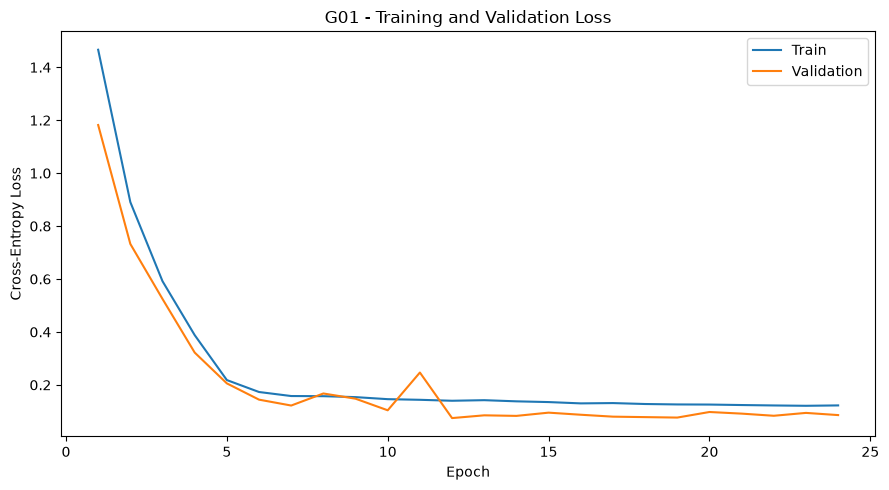

In [24]:
fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.plot(
    g01_history["epoch"],
    g01_history["train_loss"],
    label="Train",
)

ax.plot(
    g01_history["epoch"],
    g01_history["val_loss"],
    label="Validation",
)

ax.set_title(
    "G01 - Training and Validation Loss"
)

ax.set_xlabel(
    "Epoch"
)

ax.set_ylabel(
    "Cross-Entropy Loss"
)

ax.legend()

plt.tight_layout()
plt.show()

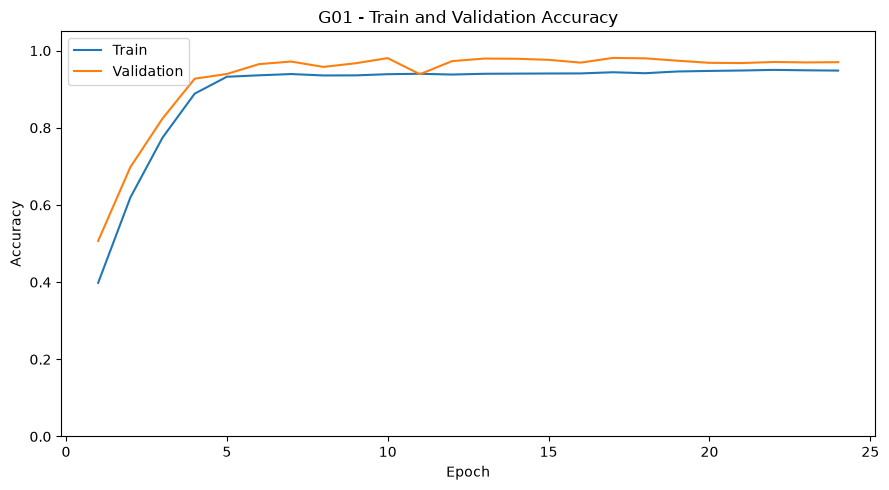

Accuracy plot saved to: C:\Users\breno\Desktop\Redes Neurais Profundas - Assessment\project_2_gru\artifacts\g01_train_validation_accuracy.png


In [25]:
fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.plot(
    g01_history["epoch"],
    g01_history["train_accuracy"],
    label="Train",
)

ax.plot(
    g01_history["epoch"],
    g01_history["val_accuracy"],
    label="Validation",
)

ax.set_title(
    "G01 - Train and Validation Accuracy"
)

ax.set_xlabel(
    "Epoch"
)

ax.set_ylabel(
    "Accuracy"
)

ax.set_ylim(
    0.0,
    1.05,
)

ax.legend()

plt.tight_layout()

g01_accuracy_path = (
    ARTIFACTS_DIR
    / "g01_train_validation_accuracy.png"
)

plt.savefig(
    g01_accuracy_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(
    f"Accuracy plot saved to: "
    f"{g01_accuracy_path}"
)

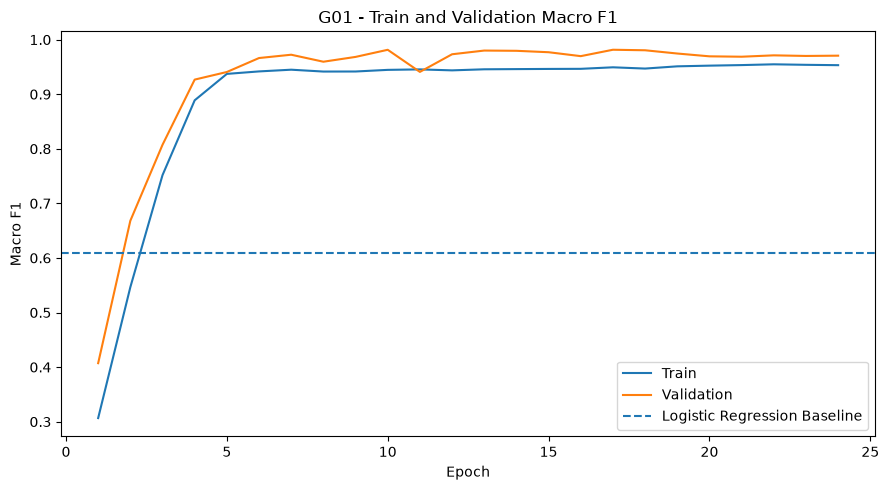

In [26]:
fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.plot(
    g01_history["epoch"],
    g01_history["train_macro_f1"],
    label="Train",
)

ax.plot(
    g01_history["epoch"],
    g01_history["val_macro_f1"],
    label="Validation",
)

ax.axhline(
    y=baseline_val_macro_f1,
    linestyle="--",
    label="Logistic Regression Baseline",
)

ax.set_title(
    "G01 - Train and Validation Macro F1"
)

ax.set_xlabel(
    "Epoch"
)

ax.set_ylabel(
    "Macro F1"
)

ax.legend()

plt.tight_layout()
plt.show()

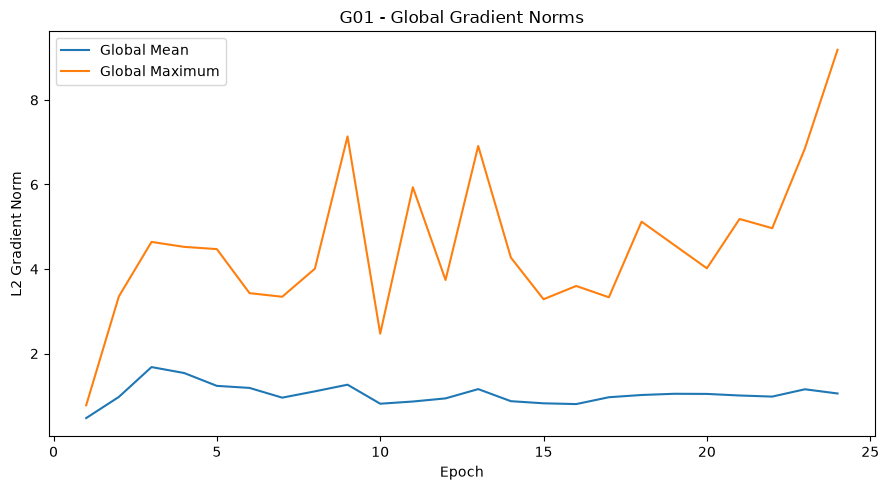

In [27]:
fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.plot(
    g01_history["epoch"],
    g01_history["grad_global_mean"],
    label="Global Mean",
)

ax.plot(
    g01_history["epoch"],
    g01_history["grad_global_max"],
    label="Global Maximum",
)

ax.set_title(
    "G01 - Global Gradient Norms"
)

ax.set_xlabel(
    "Epoch"
)

ax.set_ylabel(
    "L2 Gradient Norm"
)

ax.legend()

plt.tight_layout()
plt.show()

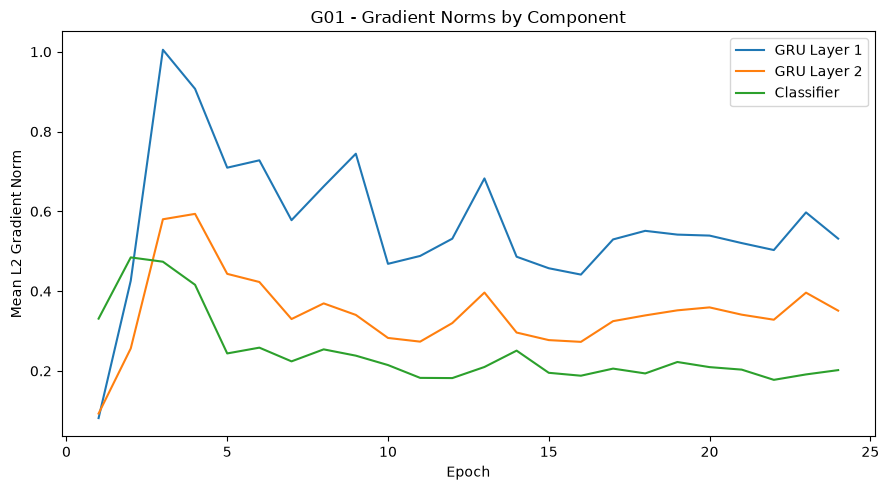

In [28]:
fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.plot(
    g01_history["epoch"],
    g01_history["grad_gru_hh_l0"],
    label="GRU Layer 1",
)

ax.plot(
    g01_history["epoch"],
    g01_history["grad_gru_hh_l1"],
    label="GRU Layer 2",
)

ax.plot(
    g01_history["epoch"],
    g01_history["grad_classifier"],
    label="Classifier",
)

ax.set_title(
    "G01 - Gradient Norms by Component"
)

ax.set_xlabel(
    "Epoch"
)

ax.set_ylabel(
    "Mean L2 Gradient Norm"
)

ax.legend()

plt.tight_layout()
plt.show()

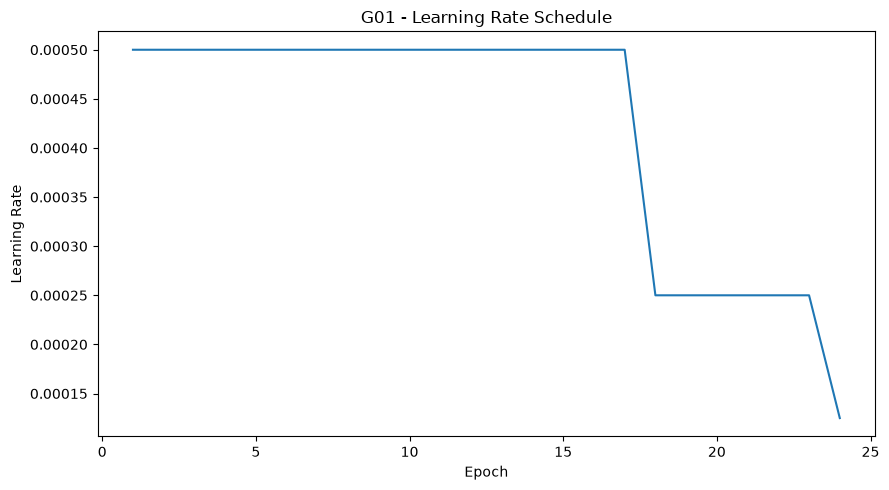

In [29]:
fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.plot(
    g01_history["epoch"],
    g01_history["learning_rate"],
)

ax.set_title(
    "G01 - Learning Rate Schedule"
)

ax.set_xlabel(
    "Epoch"
)

ax.set_ylabel(
    "Learning Rate"
)

plt.tight_layout()
plt.show()

## Análise dos erros de validação do G01

O experimento G01 apresentou convergência rápida e desempenho de validação substancialmente superior ao baseline. A melhor loss foi atingida na época 12, enquanto as épocas posteriores apresentaram pequenas oscilações sem melhoria sustentada, levando ao acionamento do scheduler e posteriormente ao early stopping.

Os gradient norms permaneceram finitos e não apresentaram evidência suficiente para caracterizar exploding gradients ou vanishing gradients. Dessa forma, não será aplicada uma correção de gradientes sem evidência objetiva.

O próximo diagnóstico será direcionado aos erros de classificação, serão analisados precision, recall e F1 de cada atividade, a matriz de confusão e a distribuição dos erros entre os participantes da validação.

In [30]:
from sklearn.metrics import confusion_matrix


def collect_gru_predictions(
    model,
    loader,
):
    model.eval()

    all_targets = []
    all_predictions = []
    all_probabilities = []

    with torch.no_grad():
        for features, targets in loader:
            features = features.to(DEVICE)

            logits = model(features)

            probabilities = torch.softmax(
                logits,
                dim=1,
            )

            predictions = logits.argmax(
                dim=1
            )

            all_targets.extend(
                targets.numpy()
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_probabilities.extend(
                probabilities.cpu().numpy()
            )

    return (
        np.asarray(all_targets),
        np.asarray(all_predictions),
        np.asarray(all_probabilities),
    )


(
    g01_val_targets,
    g01_val_predictions,
    g01_val_probabilities,
) = collect_gru_predictions(
    g01_model,
    val_loader,
)

print(
    f"Validation samples: "
    f"{len(g01_val_targets)}"
)

print(
    f"Validation errors: "
    f"{np.sum(g01_val_targets != g01_val_predictions)}"
)

print(
    f"Validation accuracy: "
    f"{accuracy_score(g01_val_targets, g01_val_predictions):.4f}"
)

print(
    f"Validation Macro F1: "
    f"{f1_score(g01_val_targets, g01_val_predictions, average='macro'):.4f}"
)

Validation samples: 1801
Validation errors: 49
Validation accuracy: 0.9728
Validation Macro F1: 0.9732


In [31]:
(
    g01_precision,
    g01_recall,
    g01_f1,
    g01_support,
) = precision_recall_fscore_support(
    g01_val_targets,
    g01_val_predictions,
    labels=list(
        ACTIVITY_NAMES.keys()
    ),
    zero_division=0,
)

g01_class_metrics = pd.DataFrame({
    "class_index": list(
        ACTIVITY_NAMES.keys()
    ),
    "activity": [
        ACTIVITY_NAMES[class_index]
        for class_index
        in ACTIVITY_NAMES.keys()
    ],
    "precision": g01_precision,
    "recall": g01_recall,
    "f1": g01_f1,
    "support": g01_support,
})

display(
    g01_class_metrics.round(4)
)

,class_index,activity,precision,recall,f1,support
0,0,WALKING,0.9739,0.9941,0.9839,338
1,1,WALKING_UPSTAIRS,0.9927,0.9855,0.9891,276
2,2,WALKING_DOWNSTAIRS,1.0000,0.9876,0.9938,242
3,3,SITTING,0.8902,0.9966,0.9404,293
4,4,STANDING,0.9930,0.8785,0.9322,321
5,5,LAYING,1.0000,1.0000,1.0000,331


In [32]:
g01_val_confusion_matrix = confusion_matrix(
    g01_val_targets,
    g01_val_predictions,
    labels=list(
        ACTIVITY_NAMES.keys()
    ),
)

confusion_matrix_dataframe = pd.DataFrame(
    g01_val_confusion_matrix,
    index=[
        ACTIVITY_NAMES[class_index]
        for class_index
        in ACTIVITY_NAMES.keys()
    ],
    columns=[
        ACTIVITY_NAMES[class_index]
        for class_index
        in ACTIVITY_NAMES.keys()
    ],
)

display(
    confusion_matrix_dataframe
)

,WALKING,WALKING_UPSTAIRS,WALKING_DOWNSTAIRS,SITTING,STANDING,LAYING
WALKING,336,2,0,0,0,0
WALKING_UPSTAIRS,4,272,0,0,0,0
WALKING_DOWNSTAIRS,1,0,239,0,2,0
SITTING,1,0,0,292,0,0
STANDING,3,0,0,36,282,0
LAYING,0,0,0,0,0,331


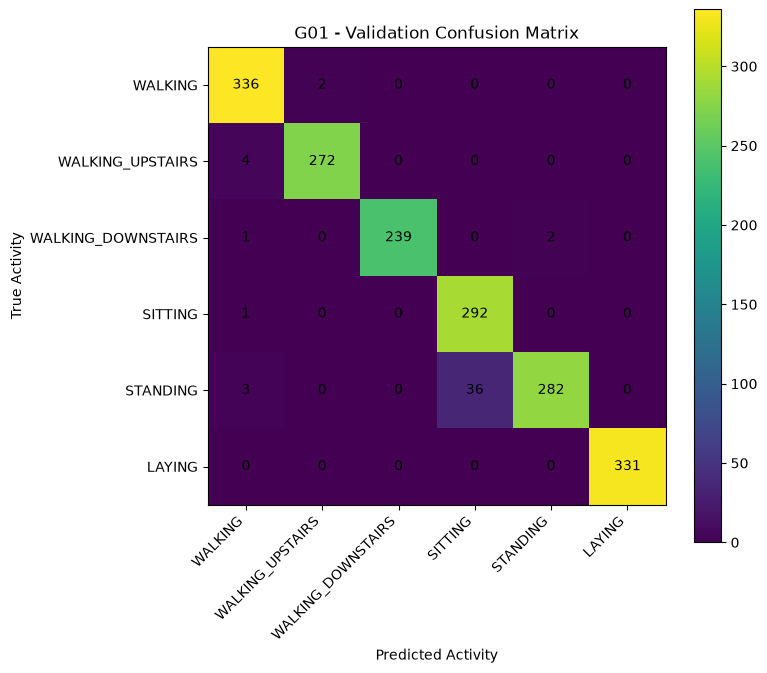

In [33]:
fig, ax = plt.subplots(
    figsize=(8, 7)
)

image = ax.imshow(
    g01_val_confusion_matrix
)

for row in range(
    g01_val_confusion_matrix.shape[0]
):
    for column in range(
        g01_val_confusion_matrix.shape[1]
    ):
        ax.text(
            column,
            row,
            g01_val_confusion_matrix[
                row,
                column,
            ],
            ha="center",
            va="center",
        )

activity_names = [
    ACTIVITY_NAMES[class_index]
    for class_index
    in ACTIVITY_NAMES.keys()
]

ax.set_xticks(
    range(NUM_CLASSES)
)

ax.set_yticks(
    range(NUM_CLASSES)
)

ax.set_xticklabels(
    activity_names,
    rotation=45,
    ha="right",
)

ax.set_yticklabels(
    activity_names
)

ax.set_xlabel(
    "Predicted Activity"
)

ax.set_ylabel(
    "True Activity"
)

ax.set_title(
    "G01 - Validation Confusion Matrix"
)

fig.colorbar(
    image,
    ax=ax,
)

plt.tight_layout()
plt.show()

In [34]:
confusion_pairs = []

for true_class in range(
    NUM_CLASSES
):
    for predicted_class in range(
        NUM_CLASSES
    ):
        if true_class == predicted_class:
            continue

        error_count = (
            g01_val_confusion_matrix[
                true_class,
                predicted_class,
            ]
        )

        if error_count > 0:
            confusion_pairs.append({
                "true_activity": (
                    ACTIVITY_NAMES[
                        true_class
                    ]
                ),
                "predicted_activity": (
                    ACTIVITY_NAMES[
                        predicted_class
                    ]
                ),
                "errors": int(
                    error_count
                ),
            })

confusion_pairs = (
    pd.DataFrame(
        confusion_pairs
    )
    .sort_values(
        by="errors",
        ascending=False,
    )
    .reset_index(
        drop=True
    )
)

display(
    confusion_pairs
)

,true_activity,predicted_activity,errors
0,STANDING,SITTING,36
1,WALKING_UPSTAIRS,WALKING,4
2,STANDING,WALKING,3
3,WALKING_DOWNSTAIRS,STANDING,2
4,WALKING,WALKING_UPSTAIRS,2
5,WALKING_DOWNSTAIRS,WALKING,1
6,SITTING,WALKING,1


In [35]:
subject_error_analysis = pd.DataFrame({
    "subject": subject_val,
    "true_class": g01_val_targets,
    "predicted_class": g01_val_predictions,
})

subject_error_analysis[
    "correct"
] = (
    subject_error_analysis[
        "true_class"
    ]
    == subject_error_analysis[
        "predicted_class"
    ]
)

subject_performance = (
    subject_error_analysis
    .groupby(
        "subject"
    )
    .agg(
        samples=(
            "correct",
            "size",
        ),
        correct=(
            "correct",
            "sum",
        ),
    )
)

subject_performance[
    "accuracy"
] = (
    subject_performance[
        "correct"
    ]
    / subject_performance[
        "samples"
    ]
)

display(
    subject_performance.round(4)
)

,samples,correct,accuracy
subject,,,
1,347,347,1.0000
3,341,334,0.9795
15,328,328,1.0000
25,409,369,0.9022
27,376,374,0.9947


In [36]:
subject_class_errors = (
    subject_error_analysis[
        ~subject_error_analysis[
            "correct"
        ]
    ]
    .copy()
)

subject_class_errors[
    "true_activity"
] = (
    subject_class_errors[
        "true_class"
    ].map(
        ACTIVITY_NAMES
    )
)

subject_class_errors[
    "predicted_activity"
] = (
    subject_class_errors[
        "predicted_class"
    ].map(
        ACTIVITY_NAMES
    )
)

subject_class_error_summary = (
    subject_class_errors
    .groupby(
        [
            "subject",
            "true_activity",
            "predicted_activity",
        ]
    )
    .size()
    .reset_index(
        name="errors"
    )
    .sort_values(
        by="errors",
        ascending=False,
    )
    .reset_index(
        drop=True
    )
)

display(
    subject_class_error_summary.head(
        20
    )
)

,subject,true_activity,predicted_activity,errors
0,25,STANDING,SITTING,36
1,3,WALKING_UPSTAIRS,WALKING,4
2,3,STANDING,WALKING,2
3,25,WALKING_DOWNSTAIRS,STANDING,2
4,27,WALKING,WALKING_UPSTAIRS,2
5,3,SITTING,WALKING,1
6,25,STANDING,WALKING,1
7,25,WALKING_DOWNSTAIRS,WALKING,1


In [37]:
g01_prediction_confidence = (
    g01_val_probabilities.max(
        axis=1
    )
)

g01_error_analysis = pd.DataFrame({
    "true_class": g01_val_targets,
    "predicted_class": g01_val_predictions,
    "confidence": g01_prediction_confidence,
})

g01_error_analysis[
    "correct"
] = (
    g01_error_analysis[
        "true_class"
    ]
    == g01_error_analysis[
        "predicted_class"
    ]
)

g01_error_analysis[
    "true_activity"
] = (
    g01_error_analysis[
        "true_class"
    ].map(
        ACTIVITY_NAMES
    )
)

g01_error_analysis[
    "predicted_activity"
] = (
    g01_error_analysis[
        "predicted_class"
    ].map(
        ACTIVITY_NAMES
    )
)

confidence_summary = (
    g01_error_analysis
    .groupby(
        "correct"
    )[
        "confidence"
    ]
    .agg(
        [
            "count",
            "mean",
            "median",
            "min",
            "max",
        ]
    )
)

display(
    confidence_summary.round(4)
)

,count,mean,median,min,max
correct,,,,,
False,49,0.7024,0.7560,0.5107,0.9656
True,1752,0.9684,0.9909,0.5124,0.9981


## Diagnóstico do problema observado no G01

Embora o G01 tenha apresentado Macro F1 de aproximadamente 0,9732, a análise por classe revelou que os erros não estão distribuídos uniformemente. Dos 49 erros observados no conjunto de validação, 36 correspondem a amostras realmente pertencentes a `STANDING` classificadas como `SITTING`, representando aproximadamente 73,5% de todos os erros.

Esse padrão reduziu o recall de `STANDING` para aproximadamente 0,8785 e a precision de `SITTING` para 0,8902, enquanto as demais atividades apresentaram desempenho substancialmente superior. A análise por participante mostrou ainda que todos os 36 erros `STANDING → SITTING` estão concentrados no participante 25, cuja accuracy foi aproximadamente 0,9022, inferior à observada nos demais participantes da validação.

Esses resultados caracterizam um problema específico de generalização intersujeito para a distinção entre duas posturas estáticas, e não uma dificuldade global da GRU em reconhecer atividades humanas.

O G01 resume cada janela de 128 timesteps utilizando exclusivamente o estado oculto produzido ao final da sequência. A hipótese formulada antes da correção é que essa representação pode atribuir peso excessivo à informação acumulada próximo ao final da janela e ser sensível às particularidades dos sinais de um participante. Como `SITTING` e `STANDING` são atividades estáticas, espera-se que uma representação agregada ao longo de toda a janela seja mais robusta para distinguir seus padrões persistentes.

Para testar essa hipótese, G02 manterá exatamente a mesma GRU, número de camadas, hidden size, Dropout, otimizador e hiperparâmetros de treinamento. A única alteração será substituir o último estado oculto pela média dos estados produzidos pela segunda camada GRU ao longo dos 128 timesteps.

In [38]:
class HARGRUMeanPool(nn.Module):
    def __init__(
        self,
        input_size,
        hidden_size,
        num_layers,
        num_classes,
        dropout_rate,
    ):
        super().__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=(
                dropout_rate
                if num_layers > 1
                else 0.0
            ),
        )

        self.classifier = nn.Linear(
            hidden_size,
            num_classes,
        )

    def forward(self, x):
        outputs, _ = self.gru(x)

        pooled_output = outputs.mean(
            dim=1
        )

        logits = self.classifier(
            pooled_output
        )

        return logits


g02_model_example = HARGRUMeanPool(
    input_size=INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    num_classes=NUM_CLASSES,
    dropout_rate=DROPOUT_RATE,
)

print(
    g02_model_example
)

print(
    f"\nG01 trainable parameters: "
    f"{count_trainable_parameters(g01_model):,}"
)

print(
    f"G02 trainable parameters: "
    f"{count_trainable_parameters(g02_model_example):,}"
)

HARGRUMeanPool(
  (gru): GRU(9, 64, num_layers=2, batch_first=True, dropout=0.3)
  (classifier): Linear(in_features=64, out_features=6, bias=True)
)

G01 trainable parameters: 39,750
G02 trainable parameters: 39,750


In [39]:
g02_model_example = (
    g02_model_example.to(DEVICE)
)

with torch.no_grad():
    g02_example_logits = (
        g02_model_example(
            example_features
        )
    )

print(
    f"Input shape: "
    f"{example_features.shape}"
)

print(
    f"Output shape: "
    f"{g02_example_logits.shape}"
)

print(
    f"Expected output shape: "
    f"(8, {NUM_CLASSES})"
)

Input shape: torch.Size([8, 128, 9])
Output shape: torch.Size([8, 6])
Expected output shape: (8, 6)


## G02 — Agregação temporal por média

O experimento G02 testa diretamente a hipótese formulada no diagnóstico, em vez de utilizar somente o último estado oculto da GRU, a representação da sequência será obtida calculando a média dos estados de saída ao longo dos 128 timesteps.

Essa alteração não modifica a quantidade de parâmetros treináveis, o objetivo é utilizar evidência proveniente da janela temporal completa, reduzindo a dependência de uma única representação final e potencialmente tornando a classificação das posturas estáticas menos sensível às características específicas de um participante. A correção será considerada favorável se reduzir principalmente os erros `STANDING → SITTING`, aumentar o recall de `STANDING` e melhorar o desempenho do participante 25, sem causar degradação relevante do Macro F1 global.

In [40]:
reset_random_seeds()

g02_model = HARGRUMeanPool(
    input_size=INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    num_classes=NUM_CLASSES,
    dropout_rate=DROPOUT_RATE,
)

(
    g02_model,
    g02_history,
    g02_checkpoint,
    g02_validation_metrics,
) = train_gru_classifier(
    model=g02_model,
    experiment_name="g02_mean_pool",
    epochs=60,
    learning_rate=5e-4,
    weight_decay=1e-4,
    scheduler_patience=5,
    early_stopping_patience=12,
)

display(
    g02_history.tail()
)

print(
    f"\nCheckpoint: "
    f"{g02_checkpoint}"
)

print(
    "\nValidation metrics:"
)

for metric_name, metric_value in (
    g02_validation_metrics.items()
):
    print(
        f"{metric_name}: "
        f"{metric_value:.4f}"
    )

Epoch 001 | Train Loss: 1.4344 | Val Loss: 1.1058 | Val Accuracy: 0.5769 | Val Macro F1: 0.4714 | Grad Mean: 0.4537 | Grad Max: 0.7440 | LR: 0.000500
Epoch 005 | Train Loss: 0.1848 | Val Loss: 0.1462 | Val Accuracy: 0.9611 | Val Macro F1: 0.9616 | Grad Mean: 0.9456 | Grad Max: 3.4696 | LR: 0.000500
Epoch 010 | Train Loss: 0.1429 | Val Loss: 0.1003 | Val Accuracy: 0.9767 | Val Macro F1: 0.9765 | Grad Mean: 0.8325 | Grad Max: 3.9932 | LR: 0.000500
Epoch 015 | Train Loss: 0.1332 | Val Loss: 0.0821 | Val Accuracy: 0.9733 | Val Macro F1: 0.9735 | Grad Mean: 0.8094 | Grad Max: 4.1685 | LR: 0.000500
Epoch 020 | Train Loss: 0.1310 | Val Loss: 0.0708 | Val Accuracy: 0.9822 | Val Macro F1: 0.9823 | Grad Mean: 0.8734 | Grad Max: 3.5259 | LR: 0.000500
Epoch 025 | Train Loss: 0.1287 | Val Loss: 0.0631 | Val Accuracy: 0.9845 | Val Macro F1: 0.9846 | Grad Mean: 0.9915 | Grad Max: 3.9429 | LR: 0.000500
Epoch 030 | Train Loss: 0.1206 | Val Loss: 0.0880 | Val Accuracy: 0.9745 | Val Macro F1: 0.9747 | Gr

,epoch,train_loss,val_loss,train_accuracy,val_accuracy,train_macro_f1,val_macro_f1,learning_rate,grad_global_mean,grad_global_max,grad_gru_hh_l0,grad_gru_hh_l1,grad_classifier
31,32,0.115073,0.060801,0.949198,0.978901,0.954051,0.979123,0.000250,0.735862,2.971524,0.352407,0.182289,0.197141
32,33,0.114390,0.074790,0.952081,0.976680,0.956663,0.977062,0.000250,0.799423,3.504400,0.384681,0.202664,0.192673
33,34,0.156752,0.087806,0.938029,0.973348,0.943468,0.973837,0.000250,1.165059,22.783729,0.535054,0.272069,0.337772
34,35,0.114602,0.066693,0.951720,0.976680,0.956360,0.977001,0.000250,0.739870,5.799419,0.344417,0.178612,0.179245
35,36,0.113826,0.069854,0.950099,0.976124,0.954870,0.976396,0.000125,0.889634,6.887223,0.410846,0.219623,0.204892



Checkpoint: C:\Users\breno\Desktop\Redes Neurais Profundas - Assessment\project_2_gru\checkpoints\gru_g02_mean_pool_best.pt

Validation metrics:
loss: 0.0574
accuracy: 0.9850
macro_f1: 0.9852


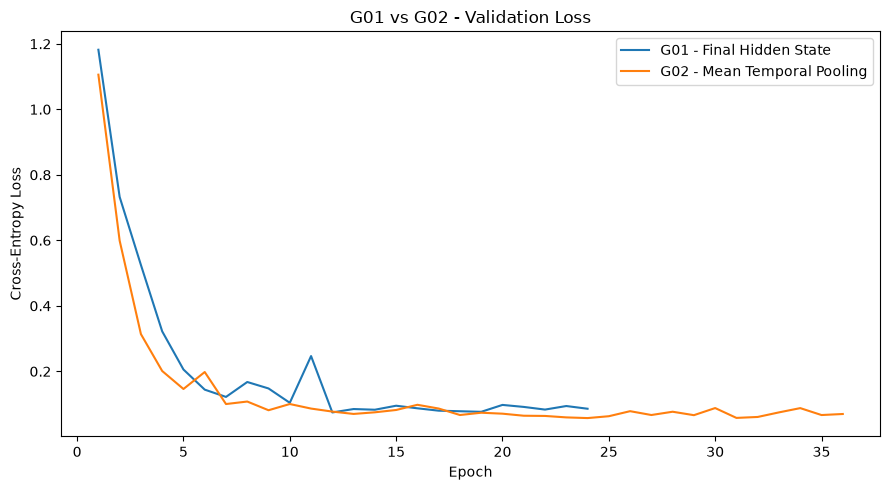

In [41]:
fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.plot(
    g01_history["epoch"],
    g01_history["val_loss"],
    label="G01 - Final Hidden State",
)

ax.plot(
    g02_history["epoch"],
    g02_history["val_loss"],
    label="G02 - Mean Temporal Pooling",
)

ax.set_title(
    "G01 vs G02 - Validation Loss"
)

ax.set_xlabel(
    "Epoch"
)

ax.set_ylabel(
    "Cross-Entropy Loss"
)

ax.legend()

plt.tight_layout()
plt.show()

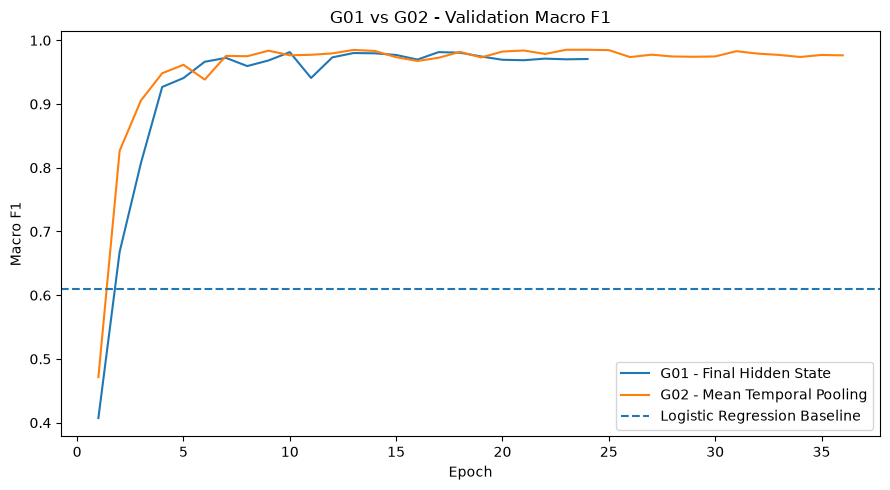

In [42]:
fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.plot(
    g01_history["epoch"],
    g01_history["val_macro_f1"],
    label="G01 - Final Hidden State",
)

ax.plot(
    g02_history["epoch"],
    g02_history["val_macro_f1"],
    label="G02 - Mean Temporal Pooling",
)

ax.axhline(
    y=baseline_val_macro_f1,
    linestyle="--",
    label="Logistic Regression Baseline",
)

ax.set_title(
    "G01 vs G02 - Validation Macro F1"
)

ax.set_xlabel(
    "Epoch"
)

ax.set_ylabel(
    "Macro F1"
)

ax.legend()

plt.tight_layout()
plt.show()

In [43]:
(
    g02_val_targets,
    g02_val_predictions,
    g02_val_probabilities,
) = collect_gru_predictions(
    g02_model,
    val_loader,
)

(
    g02_precision,
    g02_recall,
    g02_f1,
    g02_support,
) = precision_recall_fscore_support(
    g02_val_targets,
    g02_val_predictions,
    labels=list(
        ACTIVITY_NAMES.keys()
    ),
    zero_division=0,
)

g02_class_metrics = pd.DataFrame({
    "class_index": list(
        ACTIVITY_NAMES.keys()
    ),
    "activity": [
        ACTIVITY_NAMES[class_index]
        for class_index
        in ACTIVITY_NAMES.keys()
    ],
    "precision": g02_precision,
    "recall": g02_recall,
    "f1": g02_f1,
    "support": g02_support,
})

display(
    g02_class_metrics.round(4)
)

,class_index,activity,precision,recall,f1,support
0,0,WALKING,0.9768,0.9970,0.9868,338
1,1,WALKING_UPSTAIRS,0.9963,0.9819,0.9891,276
2,2,WALKING_DOWNSTAIRS,1.0000,0.9876,0.9938,242
3,3,SITTING,0.9481,0.9966,0.9717,293
4,4,STANDING,0.9935,0.9470,0.9697,321
5,5,LAYING,1.0000,1.0000,1.0000,331


In [44]:
g02_val_confusion_matrix = confusion_matrix(
    g02_val_targets,
    g02_val_predictions,
    labels=list(
        ACTIVITY_NAMES.keys()
    ),
)

g02_confusion_dataframe = pd.DataFrame(
    g02_val_confusion_matrix,
    index=[
        ACTIVITY_NAMES[class_index]
        for class_index
        in ACTIVITY_NAMES.keys()
    ],
    columns=[
        ACTIVITY_NAMES[class_index]
        for class_index
        in ACTIVITY_NAMES.keys()
    ],
)

display(
    g02_confusion_dataframe
)

,WALKING,WALKING_UPSTAIRS,WALKING_DOWNSTAIRS,SITTING,STANDING,LAYING
WALKING,337,1,0,0,0,0
WALKING_UPSTAIRS,5,271,0,0,0,0
WALKING_DOWNSTAIRS,2,0,239,0,1,0
SITTING,0,0,0,292,1,0
STANDING,1,0,0,16,304,0
LAYING,0,0,0,0,0,331


In [45]:
standing_class = next(
    class_index
    for class_index, activity_name
    in ACTIVITY_NAMES.items()
    if activity_name == "STANDING"
)

sitting_class = next(
    class_index
    for class_index, activity_name
    in ACTIVITY_NAMES.items()
    if activity_name == "SITTING"
)

g01_standing_to_sitting = int(
    g01_val_confusion_matrix[
        standing_class,
        sitting_class,
    ]
)

g02_standing_to_sitting = int(
    g02_val_confusion_matrix[
        standing_class,
        sitting_class,
    ]
)

g01_standing_recall = float(
    g01_class_metrics.loc[
        g01_class_metrics["activity"]
        == "STANDING",
        "recall",
    ].iloc[0]
)

g02_standing_recall = float(
    g02_class_metrics.loc[
        g02_class_metrics["activity"]
        == "STANDING",
        "recall",
    ].iloc[0]
)

g01_sitting_precision = float(
    g01_class_metrics.loc[
        g01_class_metrics["activity"]
        == "SITTING",
        "precision",
    ].iloc[0]
)

g02_sitting_precision = float(
    g02_class_metrics.loc[
        g02_class_metrics["activity"]
        == "SITTING",
        "precision",
    ].iloc[0]
)

diagnostic_comparison = pd.DataFrame([
    {
        "model": "G01 - Final Hidden State",
        "val_accuracy": (
            g01_validation_metrics[
                "accuracy"
            ]
        ),
        "val_macro_f1": (
            g01_validation_metrics[
                "macro_f1"
            ]
        ),
        "standing_recall": (
            g01_standing_recall
        ),
        "sitting_precision": (
            g01_sitting_precision
        ),
        "standing_to_sitting_errors": (
            g01_standing_to_sitting
        ),
    },
    {
        "model": "G02 - Mean Temporal Pooling",
        "val_accuracy": (
            g02_validation_metrics[
                "accuracy"
            ]
        ),
        "val_macro_f1": (
            g02_validation_metrics[
                "macro_f1"
            ]
        ),
        "standing_recall": (
            g02_standing_recall
        ),
        "sitting_precision": (
            g02_sitting_precision
        ),
        "standing_to_sitting_errors": (
            g02_standing_to_sitting
        ),
    },
])

display(
    diagnostic_comparison.round(4)
)

,model,val_accuracy,val_macro_f1,standing_recall,sitting_precision,standing_to_sitting_errors
0,G01 - Final Hidden State,0.9728,0.9732,0.8785,0.8902,36
1,G02 - Mean Temporal Pooling,0.9850,0.9852,0.9470,0.9481,16


In [46]:
g02_subject_error_analysis = pd.DataFrame({
    "subject": subject_val,
    "true_class": g02_val_targets,
    "predicted_class": g02_val_predictions,
})

g02_subject_error_analysis[
    "correct"
] = (
    g02_subject_error_analysis[
        "true_class"
    ]
    == g02_subject_error_analysis[
        "predicted_class"
    ]
)

g02_subject_performance = (
    g02_subject_error_analysis
    .groupby(
        "subject"
    )
    .agg(
        samples=(
            "correct",
            "size",
        ),
        correct=(
            "correct",
            "sum",
        ),
    )
)

g02_subject_performance[
    "accuracy"
] = (
    g02_subject_performance[
        "correct"
    ]
    / g02_subject_performance[
        "samples"
    ]
)

subject_25_comparison = pd.DataFrame([
    {
        "model": "G01 - Final Hidden State",
        "subject_25_accuracy": (
            subject_performance.loc[
                25,
                "accuracy",
            ]
        ),
    },
    {
        "model": "G02 - Mean Temporal Pooling",
        "subject_25_accuracy": (
            g02_subject_performance.loc[
                25,
                "accuracy",
            ]
        ),
    },
])

display(
    subject_25_comparison.round(4)
)

,model,subject_25_accuracy
0,G01 - Final Hidden State,0.9022
1,G02 - Mean Temporal Pooling,0.9438


### Resultado do diagnóstico e da correção

A hipótese formulada após a análise do G01 foi confirmada. Ao substituir o último estado oculto pela média dos estados produzidos ao longo dos 128 timesteps, G02 reduziu de 36 para 16 os erros em que amostras de `STANDING` eram classificadas como `SITTING`, uma redução de aproximadamente 55,6%.

O recall de `STANDING` aumentou de aproximadamente 0,8785 para 0,9470 e a precision de `SITTING` passou de 0,8902 para 0,9481. A melhoria também foi observada no participante 25, cuja accuracy aumentou de aproximadamente 0,9022 para 0,9438.

Além da correção do padrão específico de erro, houve melhoria global. A accuracy de validação passou de 0,9728 para 0,9850, o Macro F1 aumentou de 0,9732 para 0,9852 e a melhor loss de validação foi reduzida de aproximadamente 0,0746 para 0,0574.

Como G01 e G02 possuem exatamente a mesma quantidade de parâmetros e foram treinados com os mesmos hiperparâmetros, a melhoria pode ser associada à alteração da estratégia de agregação temporal. Os resultados indicam que utilizar informação distribuída ao longo da janela completa produziu uma representação mais robusta para as posturas estáticas e reduziu a sensibilidade às características específicas de um participante.

Os gradient norms permaneceram majoritariamente controlados, embora tenha ocorrido um pico isolado de gradient norm máximo durante o treinamento de G02, não houve crescimento persistente, divergência da loss ou outro comportamento que sustentasse um diagnóstico de exploding gradients.

## Seleção do modelo final

A configuração G02 foi selecionada como modelo final exclusivamente a partir dos resultados do conjunto de validação, antes de qualquer utilização do conjunto de teste.

A escolha foi baseada tanto no desempenho global quanto no diagnóstico específico realizado. G02 apresentou menor loss de validação, maior accuracy e maior Macro F1 que G01, além de reduzir substancialmente a principal confusão observada entre `STANDING` e `SITTING`.

A partir deste ponto, a arquitetura e os hiperparâmetros serão considerados definitivos, o conjunto de teste oficial do UCI HAR será utilizado somente para estimar a capacidade de generalização do modelo para participantes que não fizeram parte do treinamento nem da validação.

In [47]:
final_gru_model = HARGRUMeanPool(
    input_size=INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    num_classes=NUM_CLASSES,
    dropout_rate=DROPOUT_RATE,
)

final_gru_model.load_state_dict(
    torch.load(
        g02_checkpoint,
        map_location=DEVICE,
        weights_only=True,
    )
)

final_gru_model = (
    final_gru_model.to(DEVICE)
)

final_gru_model.eval()

print(
    "Best G02 checkpoint loaded successfully."
)

print(
    f"Checkpoint: {g02_checkpoint}"
)

Best G02 checkpoint loaded successfully.
Checkpoint: C:\Users\breno\Desktop\Redes Neurais Profundas - Assessment\project_2_gru\checkpoints\gru_g02_mean_pool_best.pt


In [48]:
(
    _,
    original_g02_predictions,
    original_g02_probabilities,
) = collect_gru_predictions(
    g02_model,
    val_loader,
)

(
    _,
    reloaded_g02_predictions,
    reloaded_g02_probabilities,
) = collect_gru_predictions(
    final_gru_model,
    val_loader,
)

predictions_match = np.array_equal(
    original_g02_predictions,
    reloaded_g02_predictions,
)

probabilities_match = np.allclose(
    original_g02_probabilities,
    reloaded_g02_probabilities,
    rtol=1e-6,
    atol=1e-6,
)

maximum_probability_difference = np.max(
    np.abs(
        original_g02_probabilities
        - reloaded_g02_probabilities
    )
)

print(
    f"Reloaded predictions match: "
    f"{predictions_match}"
)

print(
    f"Reloaded probabilities match: "
    f"{probabilities_match}"
)

print(
    "Maximum absolute probability difference: "
    f"{maximum_probability_difference:.10f}"
)

Reloaded predictions match: True
Reloaded probabilities match: True
Maximum absolute probability difference: 0.0000000000


## Avaliação final no conjunto de teste

A GRU será comparada à Regressão Logística utilizada como baseline, ambas foram treinadas sobre as mesmas amostras e avaliadas sobre os mesmos participantes do conjunto oficial de teste, então essa comparação permite verificar o benefício obtido pela arquitetura especializada sobre uma abordagem que utiliza as sequências achatadas.

Também será construída uma matriz de confusão e realizada uma análise por classe e por participante para investigar se o padrão de erro observado na validação se mantém em sujeitos completamente novos.

In [49]:
(
    final_test_targets,
    final_test_predictions,
    final_test_probabilities,
) = collect_gru_predictions(
    final_gru_model,
    test_loader,
)

final_test_accuracy = accuracy_score(
    final_test_targets,
    final_test_predictions,
)

final_test_macro_f1 = f1_score(
    final_test_targets,
    final_test_predictions,
    average="macro",
)

print(
    "Final GRU test metrics:"
)

print(
    f"Accuracy: "
    f"{final_test_accuracy:.4f}"
)

print(
    f"Macro F1: "
    f"{final_test_macro_f1:.4f}"
)

Final GRU test metrics:
Accuracy: 0.9250
Macro F1: 0.9260


In [50]:
baseline_test_predictions = (
    classification_baseline.predict(
        X_test_flat
    )
)

baseline_test_accuracy = accuracy_score(
    y_test,
    baseline_test_predictions,
)

baseline_test_macro_f1 = f1_score(
    y_test,
    baseline_test_predictions,
    average="macro",
)

test_model_comparison = pd.DataFrame([
    {
        "model": "Logistic Regression",
        "accuracy": baseline_test_accuracy,
        "macro_f1": baseline_test_macro_f1,
    },
    {
        "model": "GRU G02",
        "accuracy": final_test_accuracy,
        "macro_f1": final_test_macro_f1,
    },
])

display(
    test_model_comparison.round(4)
)

,model,accuracy,macro_f1
0,Logistic Regression,0.5741,0.5458
1,GRU G02,0.9250,0.9260


In [51]:
(
    final_test_precision,
    final_test_recall,
    final_test_f1,
    final_test_support,
) = precision_recall_fscore_support(
    final_test_targets,
    final_test_predictions,
    labels=list(
        ACTIVITY_NAMES.keys()
    ),
    zero_division=0,
)

final_test_class_metrics = pd.DataFrame({
    "class_index": list(
        ACTIVITY_NAMES.keys()
    ),
    "activity": [
        ACTIVITY_NAMES[class_index]
        for class_index
        in ACTIVITY_NAMES.keys()
    ],
    "precision": final_test_precision,
    "recall": final_test_recall,
    "f1": final_test_f1,
    "support": final_test_support,
})

display(
    final_test_class_metrics.round(4)
)

,class_index,activity,precision,recall,f1,support
0,0,WALKING,0.9879,0.9859,0.9869,496
1,1,WALKING_UPSTAIRS,0.9588,0.9873,0.9728,471
2,2,WALKING_DOWNSTAIRS,0.9707,0.9476,0.9590,420
3,3,SITTING,0.8294,0.7821,0.8050,491
4,4,STANDING,0.8133,0.8515,0.8320,532
5,5,LAYING,1.0000,1.0000,1.0000,537


In [52]:
final_test_confusion_matrix = confusion_matrix(
    final_test_targets,
    final_test_predictions,
    labels=list(
        ACTIVITY_NAMES.keys()
    ),
)

final_test_confusion_dataframe = pd.DataFrame(
    final_test_confusion_matrix,
    index=[
        ACTIVITY_NAMES[class_index]
        for class_index
        in ACTIVITY_NAMES.keys()
    ],
    columns=[
        ACTIVITY_NAMES[class_index]
        for class_index
        in ACTIVITY_NAMES.keys()
    ],
)

display(
    final_test_confusion_dataframe
)

,WALKING,WALKING_UPSTAIRS,WALKING_DOWNSTAIRS,SITTING,STANDING,LAYING
WALKING,489,3,4,0,0,0
WALKING_UPSTAIRS,0,465,6,0,0,0
WALKING_DOWNSTAIRS,6,16,398,0,0,0
SITTING,0,1,2,384,104,0
STANDING,0,0,0,79,453,0
LAYING,0,0,0,0,0,537


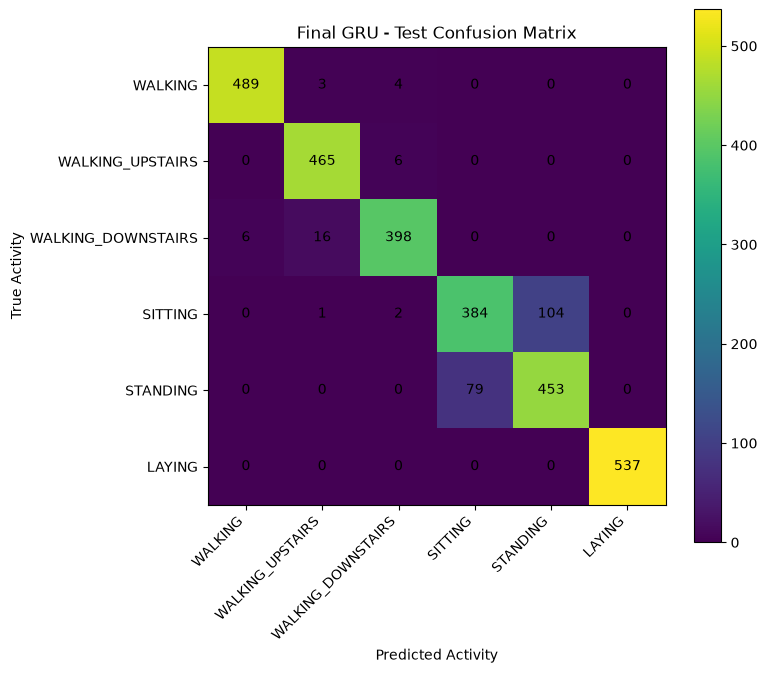

Confusion matrix saved to: C:\Users\breno\Desktop\Redes Neurais Profundas - Assessment\project_2_gru\artifacts\gru_test_confusion_matrix.png


In [53]:
fig, ax = plt.subplots(
    figsize=(8, 7)
)

image = ax.imshow(
    final_test_confusion_matrix
)

for row in range(
    NUM_CLASSES
):
    for column in range(
        NUM_CLASSES
    ):
        ax.text(
            column,
            row,
            final_test_confusion_matrix[
                row,
                column,
            ],
            ha="center",
            va="center",
        )

activity_names = [
    ACTIVITY_NAMES[class_index]
    for class_index
    in ACTIVITY_NAMES.keys()
]

ax.set_xticks(
    range(NUM_CLASSES)
)

ax.set_yticks(
    range(NUM_CLASSES)
)

ax.set_xticklabels(
    activity_names,
    rotation=45,
    ha="right",
)

ax.set_yticklabels(
    activity_names
)

ax.set_xlabel(
    "Predicted Activity"
)

ax.set_ylabel(
    "True Activity"
)

ax.set_title(
    "Final GRU - Test Confusion Matrix"
)

fig.colorbar(
    image,
    ax=ax,
)

plt.tight_layout()

test_confusion_matrix_path = (
    ARTIFACTS_DIR
    / "gru_test_confusion_matrix.png"
)

plt.savefig(
    test_confusion_matrix_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(
    f"Confusion matrix saved to: "
    f"{test_confusion_matrix_path}"
)

In [54]:
test_confusion_pairs = []

for true_class in range(
    NUM_CLASSES
):
    for predicted_class in range(
        NUM_CLASSES
    ):
        if true_class == predicted_class:
            continue

        error_count = (
            final_test_confusion_matrix[
                true_class,
                predicted_class,
            ]
        )

        if error_count > 0:
            test_confusion_pairs.append({
                "true_activity": (
                    ACTIVITY_NAMES[
                        true_class
                    ]
                ),
                "predicted_activity": (
                    ACTIVITY_NAMES[
                        predicted_class
                    ]
                ),
                "errors": int(
                    error_count
                ),
            })

test_confusion_pairs = (
    pd.DataFrame(
        test_confusion_pairs
    )
    .sort_values(
        by="errors",
        ascending=False,
    )
    .reset_index(
        drop=True
    )
)

display(
    test_confusion_pairs
)

,true_activity,predicted_activity,errors
0,SITTING,STANDING,104
1,STANDING,SITTING,79
2,WALKING_DOWNSTAIRS,WALKING_UPSTAIRS,16
3,WALKING_DOWNSTAIRS,WALKING,6
4,WALKING_UPSTAIRS,WALKING_DOWNSTAIRS,6
5,WALKING,WALKING_DOWNSTAIRS,4
6,WALKING,WALKING_UPSTAIRS,3
7,SITTING,WALKING_DOWNSTAIRS,2
8,SITTING,WALKING_UPSTAIRS,1


In [55]:
test_subject_analysis = pd.DataFrame({
    "subject": subject_test,
    "true_class": final_test_targets,
    "predicted_class": final_test_predictions,
})

test_subject_analysis[
    "correct"
] = (
    test_subject_analysis[
        "true_class"
    ]
    == test_subject_analysis[
        "predicted_class"
    ]
)

test_subject_performance = (
    test_subject_analysis
    .groupby(
        "subject"
    )
    .agg(
        samples=(
            "correct",
            "size",
        ),
        correct=(
            "correct",
            "sum",
        ),
    )
)

test_subject_performance[
    "accuracy"
] = (
    test_subject_performance[
        "correct"
    ]
    / test_subject_performance[
        "samples"
    ]
)

display(
    test_subject_performance.round(4)
)

,samples,correct,accuracy
subject,,,
2,302,271,0.8974
4,317,291,0.9180
9,288,243,0.8438
10,294,220,0.7483
12,320,318,0.9938
13,327,314,0.9602
18,364,351,0.9643
20,354,337,0.9520
24,381,381,1.0000


In [56]:
test_errors = test_subject_analysis[
    ~test_subject_analysis[
        "correct"
    ]
].copy()

test_errors[
    "true_activity"
] = (
    test_errors[
        "true_class"
    ].map(
        ACTIVITY_NAMES
    )
)

test_errors[
    "predicted_activity"
] = (
    test_errors[
        "predicted_class"
    ].map(
        ACTIVITY_NAMES
    )
)

test_error_summary = (
    test_errors
    .groupby(
        [
            "subject",
            "true_activity",
            "predicted_activity",
        ]
    )
    .size()
    .reset_index(
        name="errors"
    )
    .sort_values(
        by="errors",
        ascending=False,
    )
    .reset_index(
        drop=True
    )
)

display(
    test_error_summary.head(
        20
    )
)

,subject,true_activity,predicted_activity,errors
0,9,STANDING,SITTING,37
1,2,SITTING,STANDING,31
2,10,SITTING,STANDING,29
3,4,STANDING,SITTING,22
4,10,STANDING,SITTING,20
5,20,SITTING,STANDING,15
6,10,WALKING_DOWNSTAIRS,WALKING_UPSTAIRS,14
7,18,SITTING,STANDING,12
8,13,SITTING,STANDING,11
9,9,SITTING,STANDING,6


In [57]:
test_model_comparison_path = (
    ARTIFACTS_DIR
    / "gru_test_model_comparison.csv"
)

test_class_metrics_path = (
    ARTIFACTS_DIR
    / "gru_test_class_metrics.csv"
)

test_error_summary_path = (
    ARTIFACTS_DIR
    / "gru_test_error_analysis.csv"
)

test_model_comparison.to_csv(
    test_model_comparison_path,
    index=False,
)

final_test_class_metrics.to_csv(
    test_class_metrics_path,
    index=False,
)

test_error_summary.to_csv(
    test_error_summary_path,
    index=False,
)

print(
    f"Model comparison saved to: "
    f"{test_model_comparison_path}"
)

print(
    f"Class metrics saved to: "
    f"{test_class_metrics_path}"
)

print(
    f"Error analysis saved to: "
    f"{test_error_summary_path}"
)

Model comparison saved to: C:\Users\breno\Desktop\Redes Neurais Profundas - Assessment\project_2_gru\artifacts\gru_test_model_comparison.csv
Class metrics saved to: C:\Users\breno\Desktop\Redes Neurais Profundas - Assessment\project_2_gru\artifacts\gru_test_class_metrics.csv
Error analysis saved to: C:\Users\breno\Desktop\Redes Neurais Profundas - Assessment\project_2_gru\artifacts\gru_test_error_analysis.csv


## Interpretação dos resultados finais

A avaliação no conjunto oficial de teste resultou em accuracy de 0,9250 e Macro F1 de 0,9260 para a GRU final. O baseline de Regressão Logística obteve accuracy de 0,5741 e Macro F1 de 0,5458 e a arquitetura recorrente apresentou, portanto, ganhos absolutos de aproximadamente 35,09 pontos percentuais em accuracy e 38,02 pontos percentuais em Macro F1.

O desempenho por classe mostrou que a maior parte das atividades foi reconhecida com elevada precisão. `WALKING`, `WALKING_UPSTAIRS`, `WALKING_DOWNSTAIRS` e `LAYING` apresentaram F1 de aproximadamente 0,9869, 0,9728, 0,9590 e 1,0000, respectivamente. As principais dificuldades permaneceram concentradas nas duas posturas estáticas: `SITTING` apresentou F1 de 0,8050 e `STANDING` de 0,8320.

Dos 221 erros cometidos pela GRU no conjunto de teste, 104 foram amostras de `SITTING` classificadas como `STANDING` e 79 corresponderam ao erro inverso. Esses 183 casos representam aproximadamente 82,8% de todos os erros, mostrando que a confusão entre as duas posturas é o principal limite de generalização do modelo.

O padrão também variou entre participantes, enquanto os sujeitos 24 e 12 apresentaram accuracy de 1,0000 e 0,9938, os sujeitos 10 e 9 atingiram apenas 0,7483 e 0,8438. Como os participantes do teste não estiveram presentes no treinamento ou na validação, essa diferença evidencia uma dificuldade de generalização intersujeito.

Uma hipótese para esse comportamento é que atividades dinâmicas produzem padrões temporais de aceleração e velocidade angular mais distintos, enquanto `SITTING` e `STANDING` possuem sinais relativamente estáticos e semelhantes. Nesses casos, diferenças individuais de postura, orientação do smartphone e distribuição dos sensores podem representar uma parcela maior da variação observada. A matriz de confusão sugere, portanto, que o principal erro residual está associado à similaridade entre posturas estáticas e à variabilidade entre participantes, e não a uma incapacidade geral da GRU de modelar as sequências.

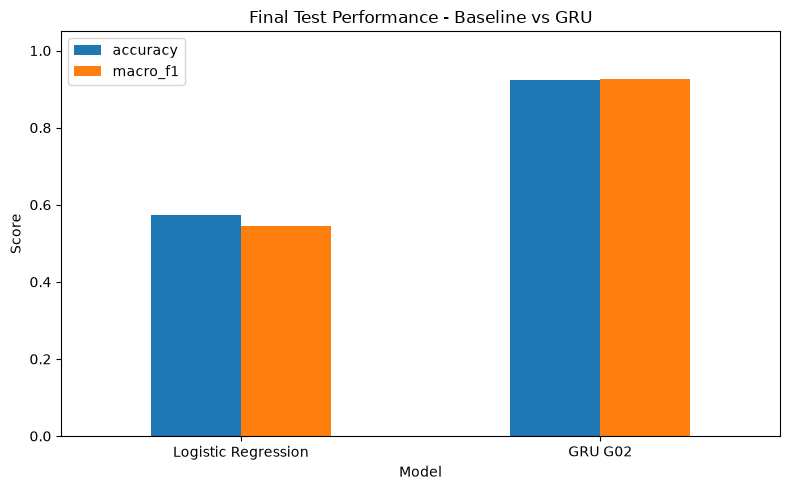

Comparison plot saved to: C:\Users\breno\Desktop\Redes Neurais Profundas - Assessment\project_2_gru\artifacts\gru_test_baseline_comparison.png


In [58]:
final_comparison_plot = (
    test_model_comparison
    .set_index("model")[
        [
            "accuracy",
            "macro_f1",
        ]
    ]
)

ax = final_comparison_plot.plot(
    kind="bar",
    figsize=(8, 5),
)

ax.set_title(
    "Final Test Performance - Baseline vs GRU"
)

ax.set_xlabel(
    "Model"
)

ax.set_ylabel(
    "Score"
)

ax.set_ylim(
    0.0,
    1.05,
)

ax.tick_params(
    axis="x",
    rotation=0,
)

plt.tight_layout()

final_comparison_plot_path = (
    ARTIFACTS_DIR
    / "gru_test_baseline_comparison.png"
)

plt.savefig(
    final_comparison_plot_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(
    f"Comparison plot saved to: "
    f"{final_comparison_plot_path}"
)

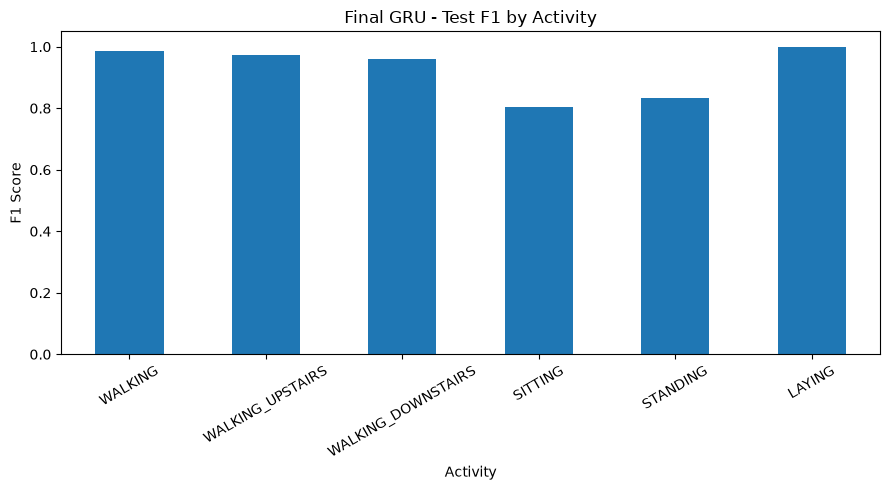

Class F1 plot saved to: C:\Users\breno\Desktop\Redes Neurais Profundas - Assessment\project_2_gru\artifacts\gru_test_f1_by_activity.png


In [59]:
ax = (
    final_test_class_metrics
    .set_index("activity")[
        "f1"
    ]
    .plot(
        kind="bar",
        figsize=(9, 5),
    )
)

ax.set_title(
    "Final GRU - Test F1 by Activity"
)

ax.set_xlabel(
    "Activity"
)

ax.set_ylabel(
    "F1 Score"
)

ax.set_ylim(
    0.0,
    1.05,
)

ax.tick_params(
    axis="x",
    rotation=30,
)

plt.tight_layout()

test_class_f1_path = (
    ARTIFACTS_DIR
    / "gru_test_f1_by_activity.png"
)

plt.savefig(
    test_class_f1_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(
    f"Class F1 plot saved to: "
    f"{test_class_f1_path}"
)

## Análise de alternativa arquitetural — CNN 1D

Uma alternativa à GRU para o mesmo problema seria uma CNN 1D aplicada diretamente às janelas multicanais de sensores. Os dados continuariam sendo representados por 128 timesteps e nove canais, mas seriam reorganizados de `[batch, 128, 9]` para `[batch, 9, 128]`, formato esperado por `Conv1d` no PyTorch. Uma configuração plausível teria três blocos convolucionais: 9→64 filtros com kernel 5, 64→128 filtros com kernel 5 e 128→128 filtros com kernel 3, utilizando padding para preservar inicialmente o comprimento da sequência. Após os primeiros blocos, `MaxPool1d` poderia reduzir gradualmente a dimensão temporal, seguido por `AdaptiveAvgPool1d(1)`, Dropout e uma camada linear com seis saídas.

O viés indutivo dessa arquitetura é diferente do utilizado pela GRU, enquanto a GRU processa os timesteps sequencialmente e mantém um estado oculto adaptativo que pode transportar informação ao longo de toda a janela, a CNN 1D procura padrões locais que podem ocorrer em diferentes posições temporais. Esse comportamento é particularmente atraente para atividades dinâmicas como caminhar, subir escadas e descer escadas, nas quais oscilações de aceleração e velocidade angular produzem motivos locais repetitivos. A convolução também compartilha pesos ao longo do tempo, favorecendo a detecção de padrões semelhantes independentemente da posição exata em que surgem dentro da janela.

Do ponto de vista computacional, a CNN 1D possui uma vantagem relevante: as convoluções de diferentes posições podem ser processadas em paralelo, enquanto a recorrência da GRU impõe dependência entre timesteps. Em hardware com GPU, isso tende a favorecer maior throughput e menor tempo de treinamento. Além disso, o receptive field pode ser controlado explicitamente por profundidade, kernel size, pooling e dilatação. Por outro lado, essa mesma característica constitui uma limitação. Uma CNN convencional depende de um receptive field definido pela arquitetura, enquanto a GRU possui um mecanismo de memória cuja influência pode se adaptar ao conteúdo da sequência. Dependências que abrangem grande parte dos 128 timesteps podem exigir mais camadas, kernels maiores ou convoluções dilatadas.

Para este dataset, a principal dificuldade observada pela GRU final foi a separação entre `SITTING` e `STANDING`, que são posturas estáticas e apresentaram grande variação entre participantes. Uma CNN 1D poderia capturar pequenas assinaturas locais dos sensores que diferenciem essas posturas, mas a invariância translacional também pode ser insuficiente quando a diferença depende mais do nível global, orientação do dispositivo ou padrão mantido durante toda a janela. Nesse caso, pooling global ou combinação de diferentes escalas de receptive field seria importante.

A viabilidade dessa alternativa é sustentada por Muralidharan K., Anirudh Ramesh, Rithvik G., Saket Prem, Reghunaath A. A. e M. P. Gopinath no artigo “1D Convolution approach to human activity recognition using sensor data and comparison with machine learning algorithms”, publicado em 2021 no International Journal of Cognitive Computing in Engineering. O trabalho utiliza sinais de acelerômetro e giroscópio de smartphones para reconhecer atividades como caminhar, sentar, ficar em pé, subir e descer escadas e deitar, demonstrando diretamente a aplicação de CNN 1D em um contexto muito semelhante ao deste projeto. DOI: 10.1016/j.ijcce.2021.09.001.

In [60]:
g01_run_dir = (
    RUNS_DIR
    / "project_2"
    / "gru"
    / "g01_base"
)

g02_run_dir = (
    RUNS_DIR
    / "project_2"
    / "gru"
    / "g02_mean_pool"
)

g01_event_files = list(
    g01_run_dir.glob(
        "events.out.tfevents.*"
    )
)

g02_event_files = list(
    g02_run_dir.glob(
        "events.out.tfevents.*"
    )
)

project_2_audit = {
    "train_validation_subject_overlap_zero": (
        len(
            train_subjects
            & val_subjects
        )
        == 0
    ),
    "train_test_subject_overlap_zero": (
        len(
            train_subjects
            & test_subjects
        )
        == 0
    ),
    "validation_test_subject_overlap_zero": (
        len(
            val_subjects
            & test_subjects
        )
        == 0
    ),
    "g01_checkpoint_exists": (
        Path(
            g01_checkpoint
        ).exists()
    ),
    "g02_checkpoint_exists": (
        Path(
            g02_checkpoint
        ).exists()
    ),
    "checkpoint_predictions_reproduced": (
        predictions_match
    ),
    "checkpoint_probabilities_reproduced": (
        probabilities_match
    ),
    "g01_tensorboard_log_exists": (
        len(
            g01_event_files
        )
        > 0
    ),
    "g02_tensorboard_log_exists": (
        len(
            g02_event_files
        )
        > 0
    ),
    "test_metrics_are_finite": (
        np.isfinite(
            final_test_accuracy
        )
        and np.isfinite(
            final_test_macro_f1
        )
    ),
    "test_confusion_matrix_exists": (
        test_confusion_matrix_path.exists()
    ),
    "test_model_comparison_exists": (
        test_model_comparison_path.exists()
    ),
    "test_class_metrics_exists": (
        test_class_metrics_path.exists()
    ),
}

audit_dataframe = pd.DataFrame(
    project_2_audit.items(),
    columns=[
        "check",
        "passed",
    ],
)

display(
    audit_dataframe
)

print(
    "\nAll Project 2 audit checks passed:",
    bool(
        audit_dataframe[
            "passed"
        ].all()
    ),
)

,check,passed
0,train_validation_subject_overlap_zero,True
1,train_test_subject_overlap_zero,True
2,validation_test_subject_overlap_zero,True
3,g01_checkpoint_exists,True
4,g02_checkpoint_exists,True
5,checkpoint_predictions_reproduced,True
6,checkpoint_probabilities_reproduced,True
7,g01_tensorboard_log_exists,True
8,g02_tensorboard_log_exists,True
9,test_metrics_are_finite,True



All Project 2 audit checks passed: True


## Conclusão do Projeto 2

O Projeto 2 aplicou o pipeline de treinamento desenvolvido anteriormente a um problema de classificação de sequências temporais utilizando sinais inerciais de smartphones. A utilização dos nove canais originais do UCI HAR preservou a estrutura de 128 timesteps de cada janela e permitiu avaliar uma arquitetura especializada em vez de depender das características estatísticas previamente extraídas pelo dataset.

A GRU com duas camadas, hidden size de 64 e Dropout de 0,3 apresentou desempenho substancialmente superior ao baseline baseado em Regressão Logística. O modelo final atingiu accuracy de 0,9250 e Macro F1 de 0,9260 no conjunto oficial de teste, enquanto o baseline obteve 0,5741 e 0,5458, respectivamente.

O treinamento também forneceu um problema real para diagnóstico, a configuração inicial G01 concentrava grande parte de seus erros na classificação de `STANDING` como `SITTING`, especialmente em um dos participantes da validação. A hipótese formulada foi que utilizar somente o último estado oculto tornava a representação excessivamente dependente da informação acumulada ao final da janela. A substituição desse mecanismo pela média dos estados temporais em G02 manteve os mesmos 39.750 parâmetros e reduziu os erros `STANDING → SITTING` de 36 para 16, além de aumentar o Macro F1 de validação de 0,9732 para 0,9852.

No conjunto de teste, a principal dificuldade continuou relacionada à separação entre `SITTING` e `STANDING`. Essas duas classes responderam por aproximadamente 82,8% dos erros, e a análise por participante mostrou diferenças substanciais de desempenho entre sujeitos. Esse resultado evidencia que a generalização intersujeito permanece como o principal desafio do modelo, especialmente para posturas estáticas com padrões inerciais semelhantes. De forma geral, os resultados demonstram a vantagem de uma arquitetura que preserva explicitamente a estrutura temporal dos sensores.